In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import joblib
import pathlib
import json

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest
import adjustText

import common_data
import common_plots
import pb_utils

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
common_plots.setup_plotting()

In [ ]:
BASE = pathlib.Path('70_degs')

# 1. Number of DEGs

In [6]:
n_degs = pd.read_csv(BASE / 'merged_counts.csv', index_col=0)

In [ ]:
COMPARISON_NAMES = {
    'alive_vs_dead': 'Survived vs. Died (all samples)',
    'alive_vs_dead_bacterial': 'Survived vs. Died (bacterial)',
    'alive_vs_dead_viral': 'Survived vs. Died (early SARS-CoV-2)',
    'alive_vs_dead_pathogen_negative': 'Survived vs. Died (pathogen-negative)',
    '[no-vap] first vs second': 'CAP/HAP/NPC then no VAP',
    '[vap] first vs second': 'CAP/HAP/NPC then VAP',
    '[baseline] no_vap vs vap': 'Future No VAP vs. Future VAP',
    'vap_cured': 'VAP will be cured vs. not cured',
    'Healthy vs Mixed': 'Healthy vs. Mixed',
    'Bacteria vs Mixed': 'Bacterial vs. Mixed',
    'Healthy vs Bacteria': 'Healthy vs. Bacterial',
    'NPC vs Bacteria': 'NPC vs. Bacterial',
    'NPC vs Mixed': 'NPC vs. Mixed',
    'Early SARS-CoV-2 vs Bacteria': 'Early SARS-CoV-2 vs. Bacterial',
    'Late SARS-CoV-2 vs Bacteria': 'Late SARS-CoV-2 vs. Bacterial',
    'Early SARS-CoV-2 vs Mixed': 'Early SARS-CoV-2 vs. Mixed',
    'Late SARS-CoV-2 vs Mixed': 'Late SARS-CoV-2 vs. Mixed',
    'Bacteria only vs Mixed': 'Bacterial vs. Mixed',
    'gram+_vs_gram-': 'Gram+ vs. Gram–',
    'pseudomonas_vs_gram-': 'Pseudomonas vs. Other Gram–',
    'age': 'Age < 65 vs. ≥ 65',
    'sex': 'Male vs. Female',
    'immunocompromised': 'Immunocompetent vs. not',
    'steroid_dose': 'Cumulative steroid dose ≤ 600 vs. > 600',
    'days_on_vent': 'Days on ventilator < 2 vs. > 16'
}

In [8]:
n_degs.rename(COMPARISON_NAMES, inplace=True)

In [ ]:
n_degs.drop([
    '[timepoint2] no_vap vs vap',
], inplace=True)

In [10]:
n_degs.columns

Index(['AT1_and_AT2', 'B_cells', 'CD4_T_cells', 'CD8_T_cells',
       'Ciliated_cells', 'Classical_monocytes-1_CCR2',
       'Classical_monocytes-2_IL1B', 'DC1', 'DC2', 'MRC1+C1QA+', 'MRC1+C1QA-',
       'Mast_cells', 'Migratory_DC', 'NUPR1+_Macs', 'Non-classical_monocytes',
       'Interstitial_macrophages', 'Plasma_cells', 'Proliferating_CD4_T_cells',
       'Proliferating_CD8_T_cells', 'Proliferating_NUPR1+_Macs',
       'Proliferating_gdT_cells', 'Proliferating_plasma_cells',
       'Secretory_cells', 'Tregs', 'gdT_cells', 'pDC'],
      dtype='object')

In [11]:
n_degs.drop(columns=[
    'DC1', 'Mast_cells', 'Migratory_DC', 'Proliferating_gdT_cells', 'pDC'
], inplace=True)

In [12]:
n_degs.columns = n_degs.columns.str.replace('_', ' ')

In [13]:
n_degs.index = n_degs.index.str.replace('vs ', 'vs. ')

In [14]:
ORDER = [
    'Healthy vs. NPC',
    'Healthy vs. Early SARS-CoV-2',
    'Healthy vs. Late SARS-CoV-2',
    'Healthy vs. Bacterial',
    'Healthy vs. Mixed',
    'NPC vs. Early SARS-CoV-2',
    'NPC vs. Late SARS-CoV-2',
    'NPC vs. Bacterial',
    'NPC vs. Mixed',
    'Early SARS-CoV-2 vs. Late SARS-CoV-2',
    'Early SARS-CoV-2 vs. Bacterial',
    'Early SARS-CoV-2 vs. Mixed',
    'Late SARS-CoV-2 vs. Bacterial',
    'Late SARS-CoV-2 vs. Mixed',
    'Bacterial vs. Mixed',
    'Gram+ vs. Gram–',
    'Pseudomonas vs. Other Gram–',

    'Survived vs. Died (all samples)',
    'Survived vs. Died (early SARS-CoV-2)',
    'Survived vs. Died (bacterial)',
    'Survived vs. Died (pathogen-negative)',

    'CAP/HAP/NPC then no VAP',
    'CAP/HAP/NPC then VAP',
    'Future No VAP vs. Future VAP',

    'VAP will be cured vs. not cured',

    'Age < 65 vs. ≥ 65',
    'Male vs. Female',
    'Immunocompetent vs. not',
    'Cumulative steroid dose ≤ 600 vs. > 600',
    'Days on ventilator < 2 vs. > 16'
]

In [15]:
n_degs = n_degs.loc[ORDER]

In [16]:
CELL_TYPE_ORDER = [
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'DC2',
    'Classical monocytes-2 IL1B',
    'Classical monocytes-1 CCR2',
    'Non-classical monocytes',
    'Interstitial macrophages',
    'Proliferating NUPR1+ Macs',

    'CD4 T cells',
    'CD8 T cells',
    'gdT cells',
    'Tregs',
    'Proliferating CD4 T cells',
    'Proliferating CD8 T cells',

    'B cells',
    'Plasma cells',
    'Proliferating plasma cells',

    'Ciliated cells',
    'Secretory cells'
]

In [17]:
MAIN_CELL_TYPE_ORDER = [
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'DC2',
    'Classical monocytes-2 IL1B',
    'Classical monocytes-1 CCR2',
    'Interstitial macrophages',
    'Proliferating NUPR1+ Macs',

    'CD4 T cells',
    'CD8 T cells',
    'gdT cells',
    'Tregs',
]

In [18]:
CELL_TYPES_DISPLAY = common_plots.CELL_TYPES_DISPLAY

In [19]:
SUPP_CELL_TYPE = pd.Series(CELL_TYPE_ORDER)
SUPP_CELL_TYPE = SUPP_CELL_TYPE[~SUPP_CELL_TYPE.isin(MAIN_CELL_TYPE_ORDER)]
supp_n_degs = n_degs.loc[:, SUPP_CELL_TYPE]

In [20]:
n_degs_plot = supp_n_degs.copy()
n_degs_plot[n_degs_plot.gt(0)] = np.log10(n_degs_plot[n_degs_plot.gt(0)])
n_degs_plot.columns = pd.Series(n_degs_plot.columns).replace(CELL_TYPES_DISPLAY)

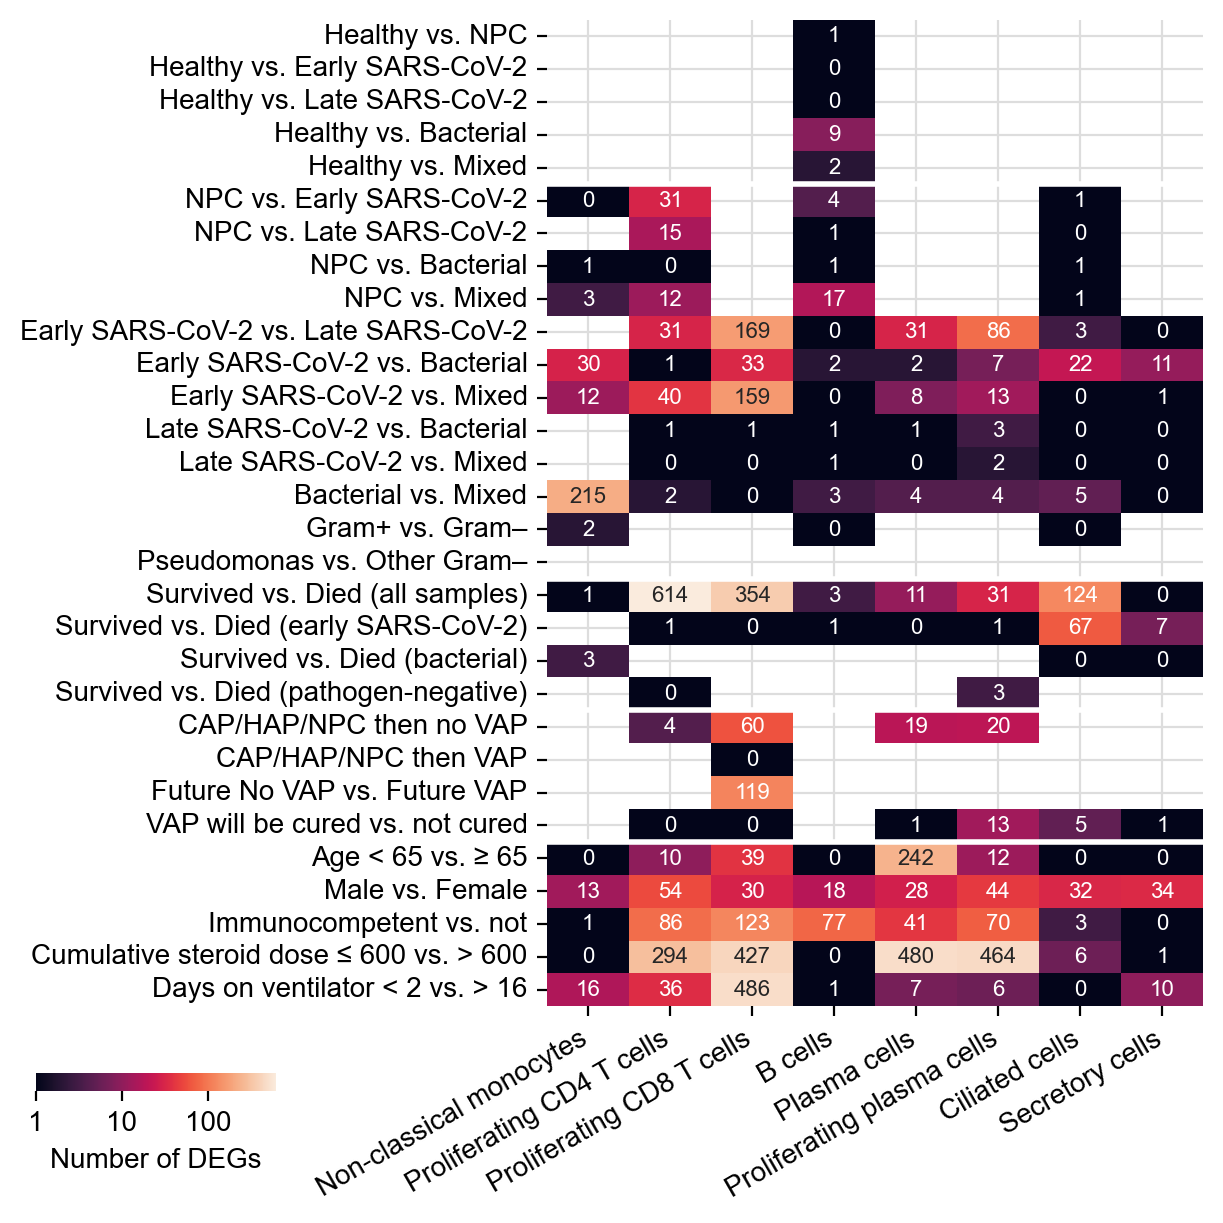

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

cbar_ax = fig.add_axes((0.02, 0.1, 0.2, 0.015))

sns.heatmap(
    n_degs_plot,
    cbar_kws=dict(
        label='Number of DEGs',
        orientation='horizontal',
        ticks=[0, 1, 2, 3]
    ),
    annot=supp_n_degs,
    fmt='.0f',
    annot_kws=dict(
        size=8
    ),
    ax=ax,
    cbar_ax=cbar_ax,
    zorder=2
)
trans = mpl.transforms.Affine2D().translate(4, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(30)
    t.set_transform(t.get_transform() + trans)
cbar_ax.set_xticklabels([1, 10, 100, 1000])

# Adding breaks for row prefixes Discharged and Timepoint
i = np.where(supp_n_degs.index.astype(str).str.startswith('NPC'))[0][0]
ax.axhline(i, color='white', lw=2)
i = np.where(supp_n_degs.index.astype(str).str.startswith('Survived'))[0][0]
ax.axhline(i, color='white', lw=2)
i = np.where(supp_n_degs.index.astype(str).str.startswith('CAP'))[0][0]
ax.axhline(i, color='white', lw=2)
i = np.where(supp_n_degs.index.astype(str).str.startswith('VAP'))[0][0] + 1
ax.axhline(i, color='white', lw=2)

ax.grid(zorder=1, c='#ddd')

fig.savefig('00_plots/70a_n_degs_supp.pdf')

In [22]:
main_n_degs = n_degs.loc[:, MAIN_CELL_TYPE_ORDER]

In [23]:
n_degs_plot = main_n_degs.copy()
n_degs_plot[n_degs_plot.gt(0)] = np.log10(n_degs_plot[n_degs_plot.gt(0)])
n_degs_plot.columns = pd.Series(n_degs_plot.columns).replace(CELL_TYPES_DISPLAY)

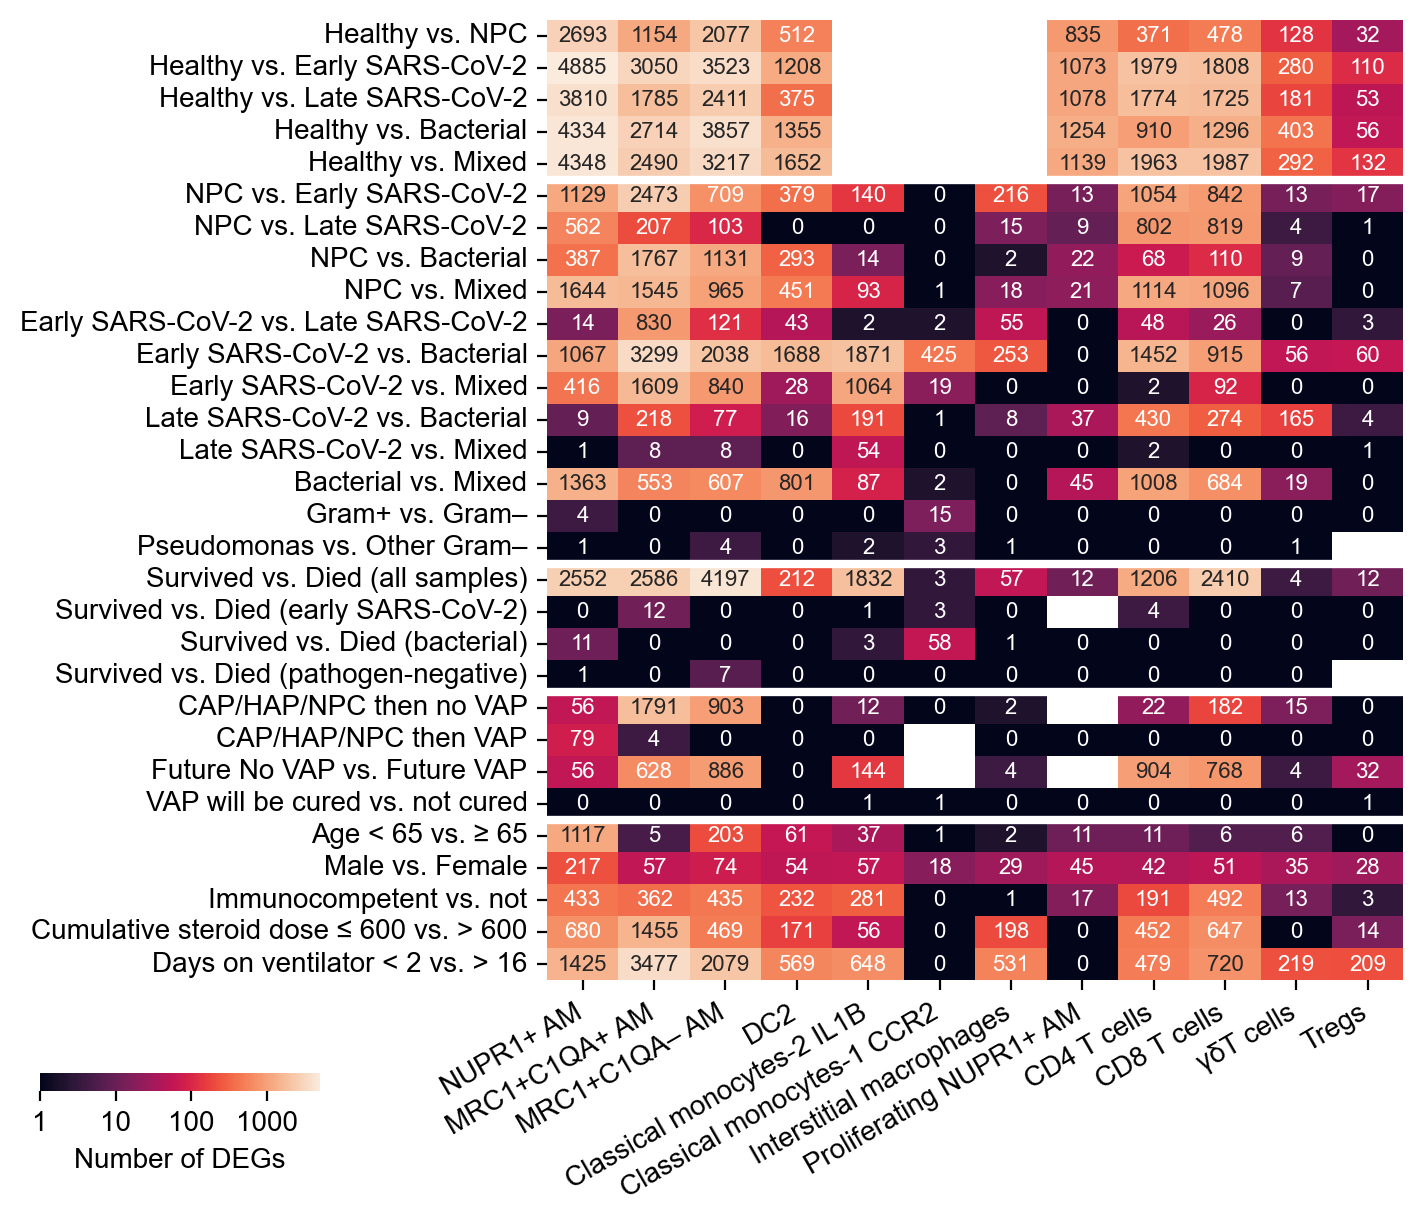

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

cbar_ax = fig.add_axes((0.02, 0.1, 0.2, 0.015))

sns.heatmap(
    n_degs_plot,
    cbar_kws=dict(
        label='Number of DEGs',
        orientation='horizontal',
        ticks=[0, 1, 2, 3]
    ),
    annot=main_n_degs,
    fmt='.0f',
    annot_kws=dict(
        size=8
    ),
    ax=ax,
    cbar_ax=cbar_ax
)
trans = mpl.transforms.Affine2D().translate(4, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(30)
    t.set_transform(t.get_transform() + trans)
cbar_ax.set_xticklabels([1, 10, 100, 1000])

# Adding breaks for row prefixes Discharged and Timepoint
i = np.where(main_n_degs.index.astype(str).str.startswith('NPC'))[0][0]
ax.axhline(i, color='white', lw=3)
i = np.where(main_n_degs.index.astype(str).str.startswith('Survived'))[0][0]
ax.axhline(i, color='white', lw=3)
i = np.where(main_n_degs.index.astype(str).str.startswith('CAP'))[0][0]
ax.axhline(i, color='white', lw=3)
i = np.where(main_n_degs.index.astype(str).str.startswith('VAP'))[0][0] + 1
ax.axhline(i, color='white', lw=3)

fig.savefig('00_plots/70a_n_degs_main.pdf')

In [ ]:
n_degs_export = n_degs.copy()
n_degs_export.columns = pd.Series(n_degs_export.columns).replace(common_plots.CELL_TYPES_DISPLAY)
n_degs_export.to_csv('../08_website/explore_dea/merged_counts.csv.gz')

# 2. Number of samples

In [26]:
comparison_stats = pd.read_csv(BASE / 'merged_stats.csv', index_col=0)

In [ ]:
# 1. Compute number of samples for the first group
first_group_samples = comparison_stats.pivot_table(
    index='task',
    columns='cell_type',
    values='group1_count'
)

# Apply the same transformations as for n_samples
first_group_samples.rename(COMPARISON_NAMES, inplace=True)

# Drop the same rows as before
first_group_samples.drop([
    '[timepoint2] no_vap vs vap'
], errors='ignore', inplace=True)

# Drop the same columns as before
first_group_samples.drop(columns=[
    'DC1', 'Mast_cells', 'Migratory_DC', 'Proliferating_gdT_cells', 'pDC'
], errors='ignore', inplace=True)

# Apply the same string replacements
first_group_samples.columns = first_group_samples.columns.str.replace('_', ' ')
first_group_samples.index = first_group_samples.index.str.replace('vs ', 'vs. ')

# Apply the same ordering
first_group_samples = first_group_samples.loc[ORDER].loc[:, CELL_TYPE_ORDER]

In [28]:
# 2. Compute number of samples for the second group
second_group_samples = comparison_stats.pivot_table(
    index='task',
    columns='cell_type',
    values='group2_count'
)

# Apply the same transformations as for n_samples
second_group_samples.rename(COMPARISON_NAMES, inplace=True)

# Drop the same rows as before
second_group_samples.drop([
    '[combined] no_vap vs vap'
], errors='ignore', inplace=True)

# Drop the same columns as before
second_group_samples.drop(columns=[
    'DC1', 'Mast_cells', 'Migratory_DC', 'Proliferating_gdT_cells', 'pDC'
], errors='ignore', inplace=True)

# Apply the same string replacements
second_group_samples.columns = second_group_samples.columns.str.replace('_', ' ')
second_group_samples.index = second_group_samples.index.str.replace('vs ', 'vs. ')

# Apply the same ordering
second_group_samples = second_group_samples.loc[ORDER].loc[:, CELL_TYPE_ORDER]

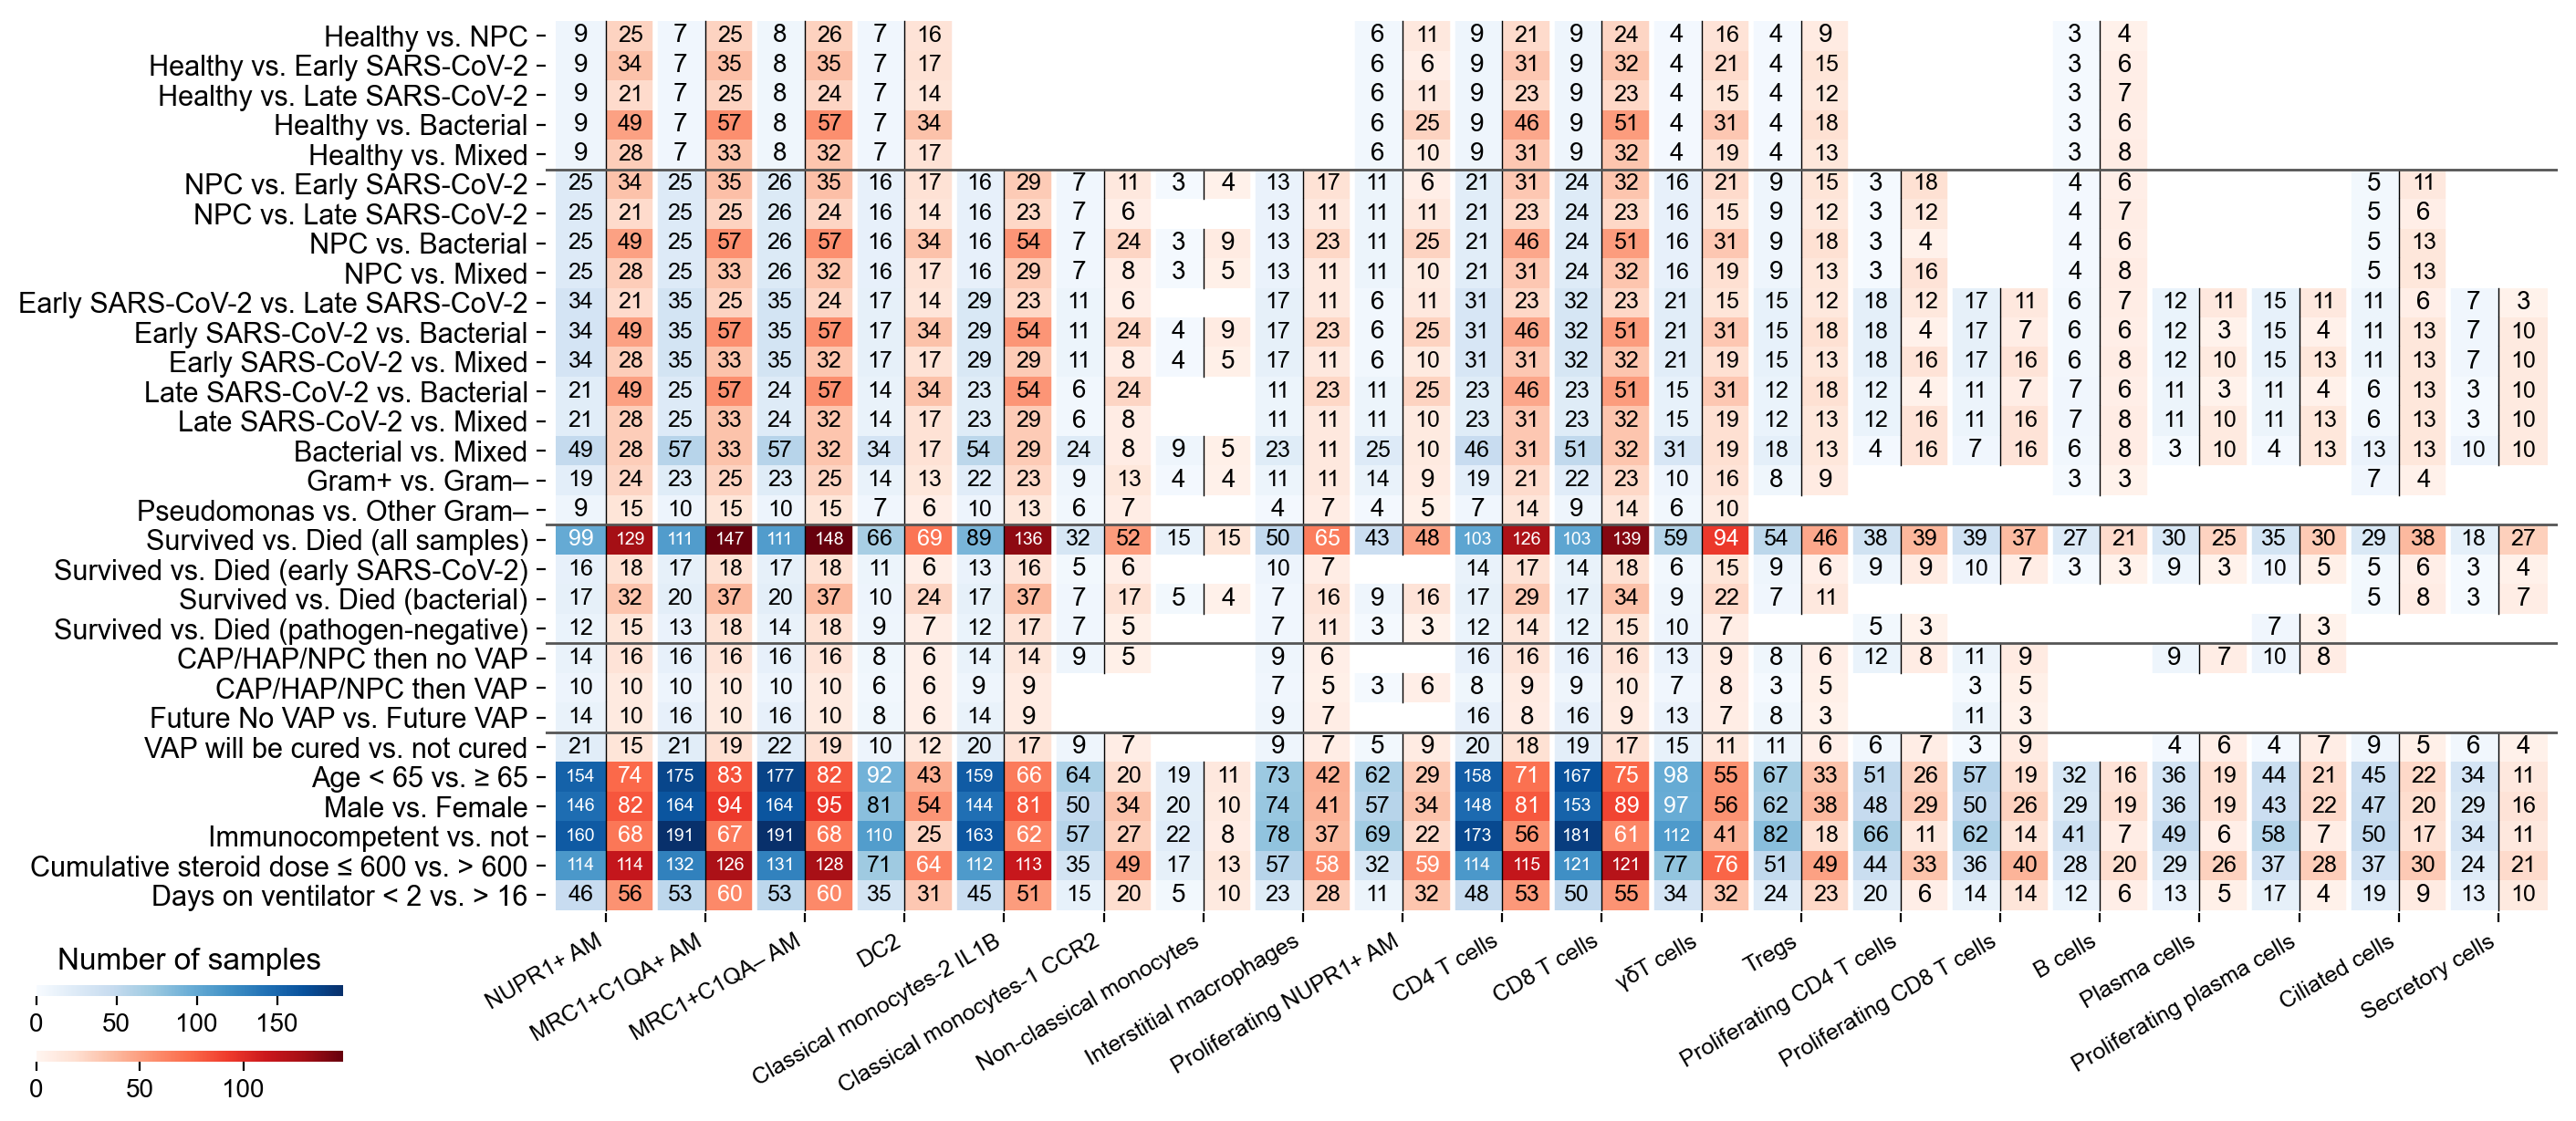

In [ ]:
# 3. Plot double heatmap with rectangles
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

# Define colormaps for the two groups
cmap_first = plt.cm.Blues
cmap_second = plt.cm.Reds

# Get global min and max for each group for normalization
min_first = first_group_samples.min().min()
max_first = first_group_samples.max().max()
min_second = second_group_samples.min().min()
max_second = second_group_samples.max().max()

# Create normalizers
norm_first = plt.Normalize(0, max_first)
norm_second = plt.Normalize(0, max_second)

# Width of each rectangle (cell type)
rect_width = 1
rect_height = 1

# Plot rectangles for each cell type and comparison
for i, comparison in enumerate(first_group_samples.index):
    for j, cell_type in enumerate(CELL_TYPE_ORDER):
        # First group rectangle (left half)
        first_value = first_group_samples.loc[comparison, cell_type]
        if not np.isnan(first_value):
            first_color = cmap_first(norm_first(first_value))
            _coords = (j, i)
            _w = rect_width / 2
            _h = rect_height
            rect_first = plt.Rectangle(_coords, _w, _h, facecolor=first_color)#, edgecolor='grey', linewidth=0.5)
            ax.add_patch(rect_first)
            lum = sns.utils.relative_luminance(first_color)
            text_color = 'black' if lum > .408 else 'white'
            first_value = int(first_value)
            text_size = 10 if first_value < 10 else 9 if first_value < 100 else 7
            ax.text(_coords[0] + rect_width / 4, _coords[1] + _h / 2, int(first_value),
                   ha='center', va='center', fontsize=text_size, color=text_color)

        # Second group rectangle (right half)
        second_value = second_group_samples.loc[comparison, cell_type]
        if not np.isnan(second_value):
            second_color = cmap_second(norm_second(second_value))
            _coords = (j + rect_width / 2, i)
            _w = rect_width / 2
            _h = rect_height
            rect_second = plt.Rectangle(_coords, _w, _h, facecolor=second_color)#, edgecolor='grey', linewidth=0.5)
            ax.add_patch(rect_second)
            lum = sns.utils.relative_luminance(second_color)
            text_color = 'black' if lum > .408 else 'white'
            first_value = int(second_value)
            text_size = 10 if second_value < 10 else 9 if second_value < 100 else 7
            ax.text(_coords[0] + rect_width / 4, _coords[1] + _h / 2, int(second_value),
                   ha='center', va='center', fontsize=text_size, color=text_color)
            ax.plot([_coords[0], _coords[0]], [_coords[1] + rect_height, _coords[1]], color='black', lw=0.5, zorder=1)
            # ax.plot(
            #     [j, j, j + rect_width, j + rect_width],
            #     [i, i + rect_height, i + rect_height, i],
            #     color='white', lw=3.5, zorder=2
            # )


# Set y-ticks with comparison names
ax.set_yticks(np.arange(len(n_degs.index)) + 0.5)
ax.set_yticklabels(n_degs.index, fontsize=11)

# Set x-ticks with cell type names
ax.set_xticks(np.arange(len(CELL_TYPE_ORDER)) + 0.5)
ax.set_xticklabels(pd.Series(CELL_TYPE_ORDER).replace(CELL_TYPES_DISPLAY), fontsize=9, rotation=30, ha='right')

for i in range(len(CELL_TYPE_ORDER) - 1):
    ax.axvline(i + 1, color='w', lw=2, zorder=1)

# Set axis limits
ax.set_xlim(-0.1, len(CELL_TYPE_ORDER) + 0.1)
ax.set_ylim(len(n_degs.index) + 0.1, -0.1)

# Add colorbar for first group
cax_first = fig.add_axes((0.01, 0.1, 0.12, 0.01))
cb_first = plt.colorbar(plt.cm.ScalarMappable(norm=norm_first, cmap=cmap_first),
                      cax=cax_first, orientation='horizontal')
# cb_first.set_label('Number of samples (first group)', fontsize=12)
cax_first.set_title('Number of samples', fontsize=12)

# Add colorbar for second group
cax_second = fig.add_axes((0.01, 0.04, 0.12, 0.01))
cb_second = plt.colorbar(plt.cm.ScalarMappable(norm=norm_second, cmap=cmap_second),
                       cax=cax_second, orientation='horizontal')
for spine in cax_first.spines:
    cax_first.spines[spine].set_visible(False)
for spine in cax_second.spines:
    cax_second.spines[spine].set_visible(False)
# cb_second.set_label('Number of samples (second group)', fontsize=12)

# Adding breaks for row prefixes Discharged and Timepoint
line_style = dict(color='#555', lw=1)
i = np.where(n_degs.index.astype(str).str.startswith('NPC'))[0][0]
ax.axhline(i, **line_style)
i = np.where(n_degs.index.astype(str).str.startswith('Survived'))[0][0]
ax.axhline(i, **line_style)
i = np.where(n_degs.index.astype(str).str.startswith('CAP'))[0][0]
ax.axhline(i, **line_style)
i = np.where(n_degs.index.astype(str).str.startswith('VAP'))[0][0]
ax.axhline(i, **line_style)

# Set title
# ax.set_title('Sample counts for comparison groups', fontsize=12)

for spine in ax.spines:
    ax.spines[spine].set_visible(False)

# Uncomment to save the figure
fig.savefig('00_plots/70a_sample_counts.pdf')

In [30]:
COMPARISON_2_SIDES = {
    'Survived vs. Died (all samples)': ('Survived', 'Died'),
    'Survived vs. Died (early SARS-CoV-2)': ('Survived', 'Died'),
    'Survived vs. Died (bacterial)': ('Survived', 'Died'),
    'Survived vs. Died (pathogen-negative)': ('Survived', 'Died'),

    'CAP/HAP/NPC then no VAP': ('CAP/HAP/NPC (timepoint 1)', 'no VAP (timepoint 2)'),
    'CAP/HAP/NPC then VAP': ('CAP/HAP/NPC (timepoint 1)', 'VAP (timepoint 2)'),

    'Age < 65 vs. ≥ 65': ('Age < 65', 'Age ≥ 65'),
    'Immunocompetent vs. not': ('Immunocompetent', 'Immunocompromised'),
    'Cumulative steroid dose ≤ 600 vs. > 600': ('Steroid dose ≤ 600', 'Steroid dose > 600'),
    'Days on ventilator < 2 vs. > 16': ('< 2 ventilator days', '> 16 ventilator days')
}

In [ ]:
comparison_stats_export = comparison_stats.copy()
comparison_stats_export.task = comparison_stats_export.task.replace(COMPARISON_NAMES).str.replace('vs ', 'vs. ')
comparison_stats_export = comparison_stats_export.loc[comparison_stats_export.task.isin(ORDER)]
comparison_stats_export.cell_type = comparison_stats_export.cell_type.str.replace('_', ' ').replace(common_plots.CELL_TYPES_DISPLAY)
for comp in comparison_stats_export.task.unique():
    sides = COMPARISON_2_SIDES.get(comp, comp.split(' vs. '))
    comparison_stats_export.loc[comparison_stats_export.task.eq(comp), 'group1'] = sides[0]
    comparison_stats_export.loc[comparison_stats_export.task.eq(comp), 'group2'] = sides[1]
comparison_stats_export.to_csv('../08_website/explore_dea/merged_stats.csv.gz')


# 3. GSEA pathogens healthy

1. Healthy vs Early SARS-CoV-2
2. Healthy vs Late SARS-CoV-2
3. Healthy vs Bacteria
4. Healthy vs Mixed

In [32]:
DROP_BOTTOM_BASEMEAN = 0.2
PADJ_CUTOFF = 0.05
class ComparisonInfo:
    def __init__(self, control, condition, genes, genes_to_keep):
        self.control = control
        self.condition = condition
        self.genes_raw = genes
        self.filter_genes(genes_to_keep)

    def filter_genes(self, genes_to_keep):
        filtered_degs = self.genes_raw.loc[self.genes_raw.index.isin(genes_to_keep), :].copy()
        filtered_degs = filtered_degs.loc[filtered_degs.pvalue.notna()].copy()
        basemean = filtered_degs.baseMean.quantile(DROP_BOTTOM_BASEMEAN)
        filtered_degs = filtered_degs.loc[filtered_degs.baseMean.gt(basemean)].copy()
        # recompute FDR correction on the filtered genes:
        filtered_degs['padj'] = statsmodels.stats.multitest.fdrcorrection(
            filtered_degs.pvalue,
            alpha=PADJ_CUTOFF
        )[1]
        # recompute gene status based on new `padj`
        filtered_degs['sign'] = ''
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.gt(0),
            'sign'
        ] = f'Up in {self.condition}'
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.lt(0),
            'sign'
        ] = f'Up in {self.control}'
        self.genes = filtered_degs


class CellTypeInfo:
    def __init__(self, path, task_info, genes_to_keep):
        self.path = path
        self.task_info = task_info
        self.comparisons = []
        self.meta = pd.read_csv(path / 'meta.csv', index_col=0)
        self.name = self.meta.cell_type.values[0]

        self.load_comparisons(genes_to_keep)

    def load_comparisons(self, genes_to_keep):
        for run in self.path.glob('**/degs.csv'):
            self.comparisons.append(
                ComparisonInfo(
                    self.task_info.column_values[0],
                    self.task_info.column_values[1],
                    pd.read_csv(run, index_col=0),
                    genes_to_keep[self.name]
                )
            )

    @property
    def n_comparisons(self):
        return len(self.comparisons)

In [33]:
class TaskData:
    def __init__(self, task, task_info):
        self.task = task
        self.task_info = task_info
        self.info = {}

In [ ]:
data = joblib.load('31b_deg_data.joblib')

In [ ]:
PATHOGEN_BASE = pathlib.Path('../data/05_pseudobulk/30b_degs')

In [36]:
result = {}
for _, task in data.items():
    gseas = []
    for k, ct_info in task.info.items():
        comp = ct_info.comparisons[0]
        gsea_path = PATHOGEN_BASE / task.task_info.pathname / k / 'gsea.csv'
        if not gsea_path.exists():
            print(f'No GSEA for {k} in {task.task_info.pathname}')
            continue
        gsea = pd.read_csv(gsea_path, index_col=0)
        gsea['cell_type'] = k
        if k == 'Perivascular_macrophages':
            gsea['cell_type'] = 'Interstitial_macrophages'
        gseas.append(gsea)
    result[task.task_info.pathname] = pd.concat(gseas)

In [37]:
GSEA_LIST = [
    'HALLMARK_INFLAMMATORY_RESPONSE',
    'HALLMARK_INTERFERON_ALPHA_RESPONSE',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
    'HALLMARK_IL6_JAK_STAT3_SIGNALING',
    'HALLMARK_IL2_STAT5_SIGNALING',
    'HALLMARK_COMPLEMENT',
    'HALLMARK_COAGULATION',
    'HALLMARK_ALLOGRAFT_REJECTION',
    'HALLMARK_PROTEIN_SECRETION',
    'HALLMARK_G2M_CHECKPOINT',
    'HALLMARK_MITOTIC_SPINDLE',
    'HALLMARK_PI3K_AKT_MTOR_SIGNALING',
    'HALLMARK_MTORC1_SIGNALING',
    'HALLMARK_E2F_TARGETS',
    'HALLMARK_APOPTOSIS',

    'HALLMARK_HYPOXIA',
    'HALLMARK_GLYCOLYSIS',
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_FATTY_ACID_METABOLISM',
    'HALLMARK_PEROXISOME',
    'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY',
    'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
    'HALLMARK_XENOBIOTIC_METABOLISM',

    'HALLMARK_ANDROGEN_RESPONSE',
    'HALLMARK_ESTROGEN_RESPONSE_EARLY',
    'HALLMARK_ESTROGEN_RESPONSE_LATE',

    'HALLMARK_DNA_REPAIR',
    'HALLMARK_TGF_BETA_SIGNALING',
    'HALLMARK_ANGIOGENESIS',
    'HALLMARK_NOTCH_SIGNALING'
]

In [38]:
GSEAS_TO_PLOT = [
    'H_vs_eCOVID', 'H_vs_Bac', 'H_vs_Mix'
]

In [39]:
to_plot = []
for gsea_name in GSEAS_TO_PLOT:
    gsea = result[gsea_name]
    gsea['p-value'] = gsea['NOM p-value'].copy()
    idx = gsea['p-value'].eq(0)
    min_p_val = gsea['p-value'][~idx].min()
    gsea.loc[idx, 'p-value'] = min_p_val * 0.1

    print(f'P-values exactly 0: {idx.sum()} in {gsea_name}')

    gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
    gsea['-log10(padj)'] = -np.log10(gsea.padj)
    gsea['-log10(padj)'] *= np.sign(gsea.NES)
    gsea_df = gsea.pivot_table(
        index='cell_type',
        columns='Term',
        values='-log10(padj)'
    )
    gsea_df = gsea_df.loc[:, GSEA_LIST]
    gsea_df.index = gsea_df.index.str.replace('_', ' ')

    gsea_df_plot = gsea_df.fillna(0).T
    to_plot.append(gsea_df_plot)

P-values exactly 0: 22 in H_vs_eCOVID
P-values exactly 0: 20 in H_vs_Bac
P-values exactly 0: 32 in H_vs_Mix


In [40]:
plot_min = min([x.min().min() for x in to_plot])
plot_max = min([x.max().max() for x in to_plot])

In [41]:
TITLES = {
    'H_vs_eCOVID': 'Healthy vs. Early SARS-CoV-2',
    'H_vs_Bac': 'Healthy vs. Bacterial',
    'H_vs_Mix': 'Healthy vs. Mixed infection'
}

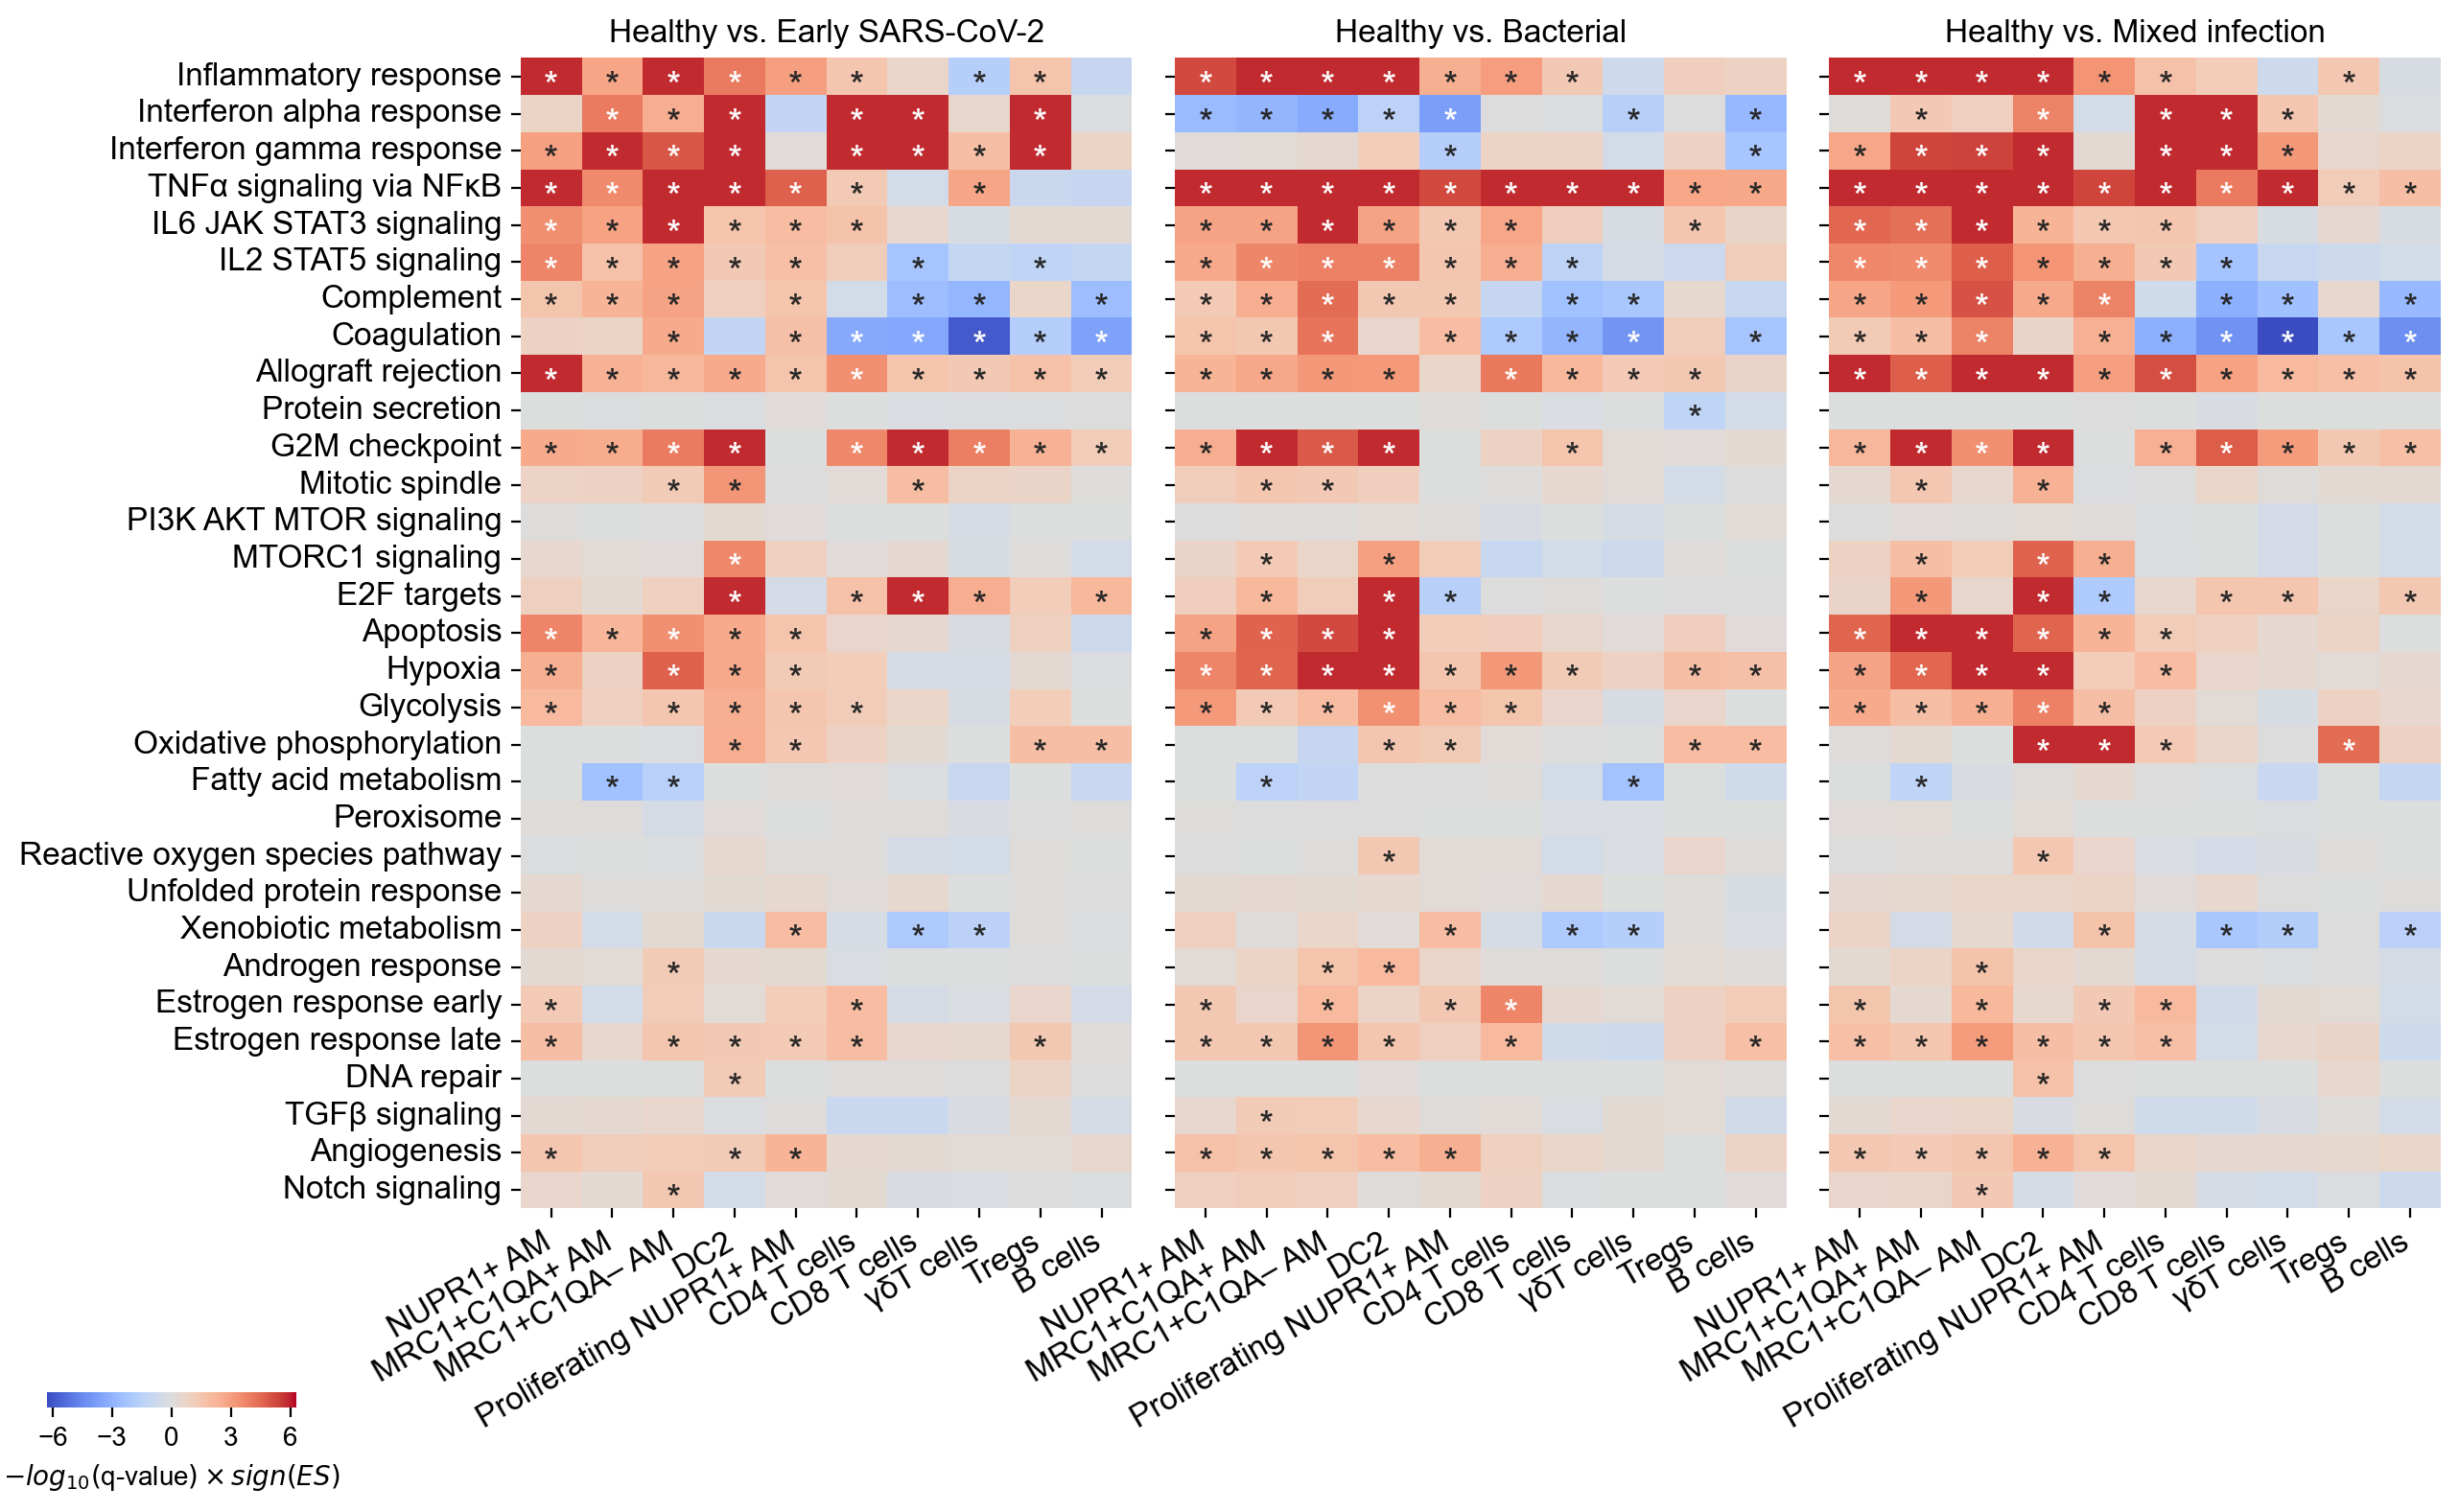

In [ ]:
fig, axes = plt.subplots(
    1, len(GSEAS_TO_PLOT), constrained_layout=False,
    figsize=(13, 8), sharey=True, gridspec_kw=dict(wspace=0.07)
)
for i, gsea_df_plot in enumerate(to_plot):
    ax = axes[i]

    present_cell_types = pd.Series(CELL_TYPE_ORDER)
    present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
    gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]
    gsea_df_plot.columns = pd.Series(gsea_df_plot.columns).replace(CELL_TYPES_DISPLAY)

    rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

    stars = np.empty_like(gsea_df_plot, dtype=str)
    stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

    cg = sns.heatmap(
        gsea_df_plot,
        cbar=False,
        xticklabels=gsea_df_plot.columns,
        yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
        cmap='coolwarm',
        annot=stars,
        fmt='',
        annot_kws=dict(
            va='center_baseline',
            fontsize=14
        ),
        ax=ax,
        vmin=plot_min,
        vmax=plot_max,
        center=0
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(
        ax.get_xticklabels(),
        fontsize=12,
        rotation=30,
        ha='right'
    )
    ax.set_title(TITLES[GSEAS_TO_PLOT[i]], fontsize=12)
    trans = mpl.transforms.Affine2D().translate(5, 0)
    for t in ax.get_xticklabels():
        t.set_transform(t.get_transform() + trans)
    for t in ax.texts:
        if t.get_text() == '*':
            p = t.get_position()
            t.set_position((p[0], p[1] + 0.2))
    if i == 0:
        ax.tick_params(axis='y', labelsize=12)

norm = mpl.colors.CenteredNorm(vcenter=0)
norm.vmin = plot_min
norm.vmax = plot_max
cax = fig.add_axes((0.03, 0.07, 0.1, 0.01))
mappable = mpl.cm.ScalarMappable(norm, cmap='coolwarm')
cbar = plt.colorbar(mappable, cax=cax, orientation='horizontal')
for spine in cax.spines:
    cax.spines[spine].set_visible(False)
cax.set_xlabel('$-log_{10}($q-value$) \\times sign(ES)$')
cax.set_xticks([-6, -3, 0, 3, 6])
fig.subplots_adjust(left=0.22, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70a_gsea_pathogens_healthy.pdf')

In [43]:
GSEAS_TO_PLOT = [
    'N_vs_eCOVID', 'N_vs_Bac', 'N_vs_Mix'
]

In [44]:
to_plot = []
for gsea_name in GSEAS_TO_PLOT:
    gsea = result[gsea_name]
    gsea['p-value'] = gsea['NOM p-value'].copy()
    idx = gsea['p-value'].eq(0)
    min_p_val = gsea['p-value'][~idx].min()
    gsea.loc[idx, 'p-value'] = min_p_val * 0.1

    print(f'P-values exactly 0: {idx.sum()} in {gsea_name}')

    gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
    gsea['-log10(padj)'] = -np.log10(gsea.padj)
    gsea['-log10(padj)'] *= np.sign(gsea.NES)
    gsea_df = gsea.pivot_table(
        index='cell_type',
        columns='Term',
        values='-log10(padj)'
    )
    gsea_df = gsea_df.loc[:, GSEA_LIST]
    gsea_df.index = gsea_df.index.str.replace('_', ' ')

    gsea_df_plot = gsea_df.fillna(0).T
    to_plot.append(gsea_df_plot)

P-values exactly 0: 49 in N_vs_eCOVID
P-values exactly 0: 35 in N_vs_Bac
P-values exactly 0: 59 in N_vs_Mix


In [45]:
plot_min = min([x.min().min() for x in to_plot])
plot_max = min([x.max().max() for x in to_plot])

In [46]:
TITLES = {
    'N_vs_eCOVID': 'NPC vs. Early SARS-CoV-2',
    'N_vs_Bac': 'NPC vs. Bacterial',
    'N_vs_Mix': 'NPC vs. Mixed infection'
}

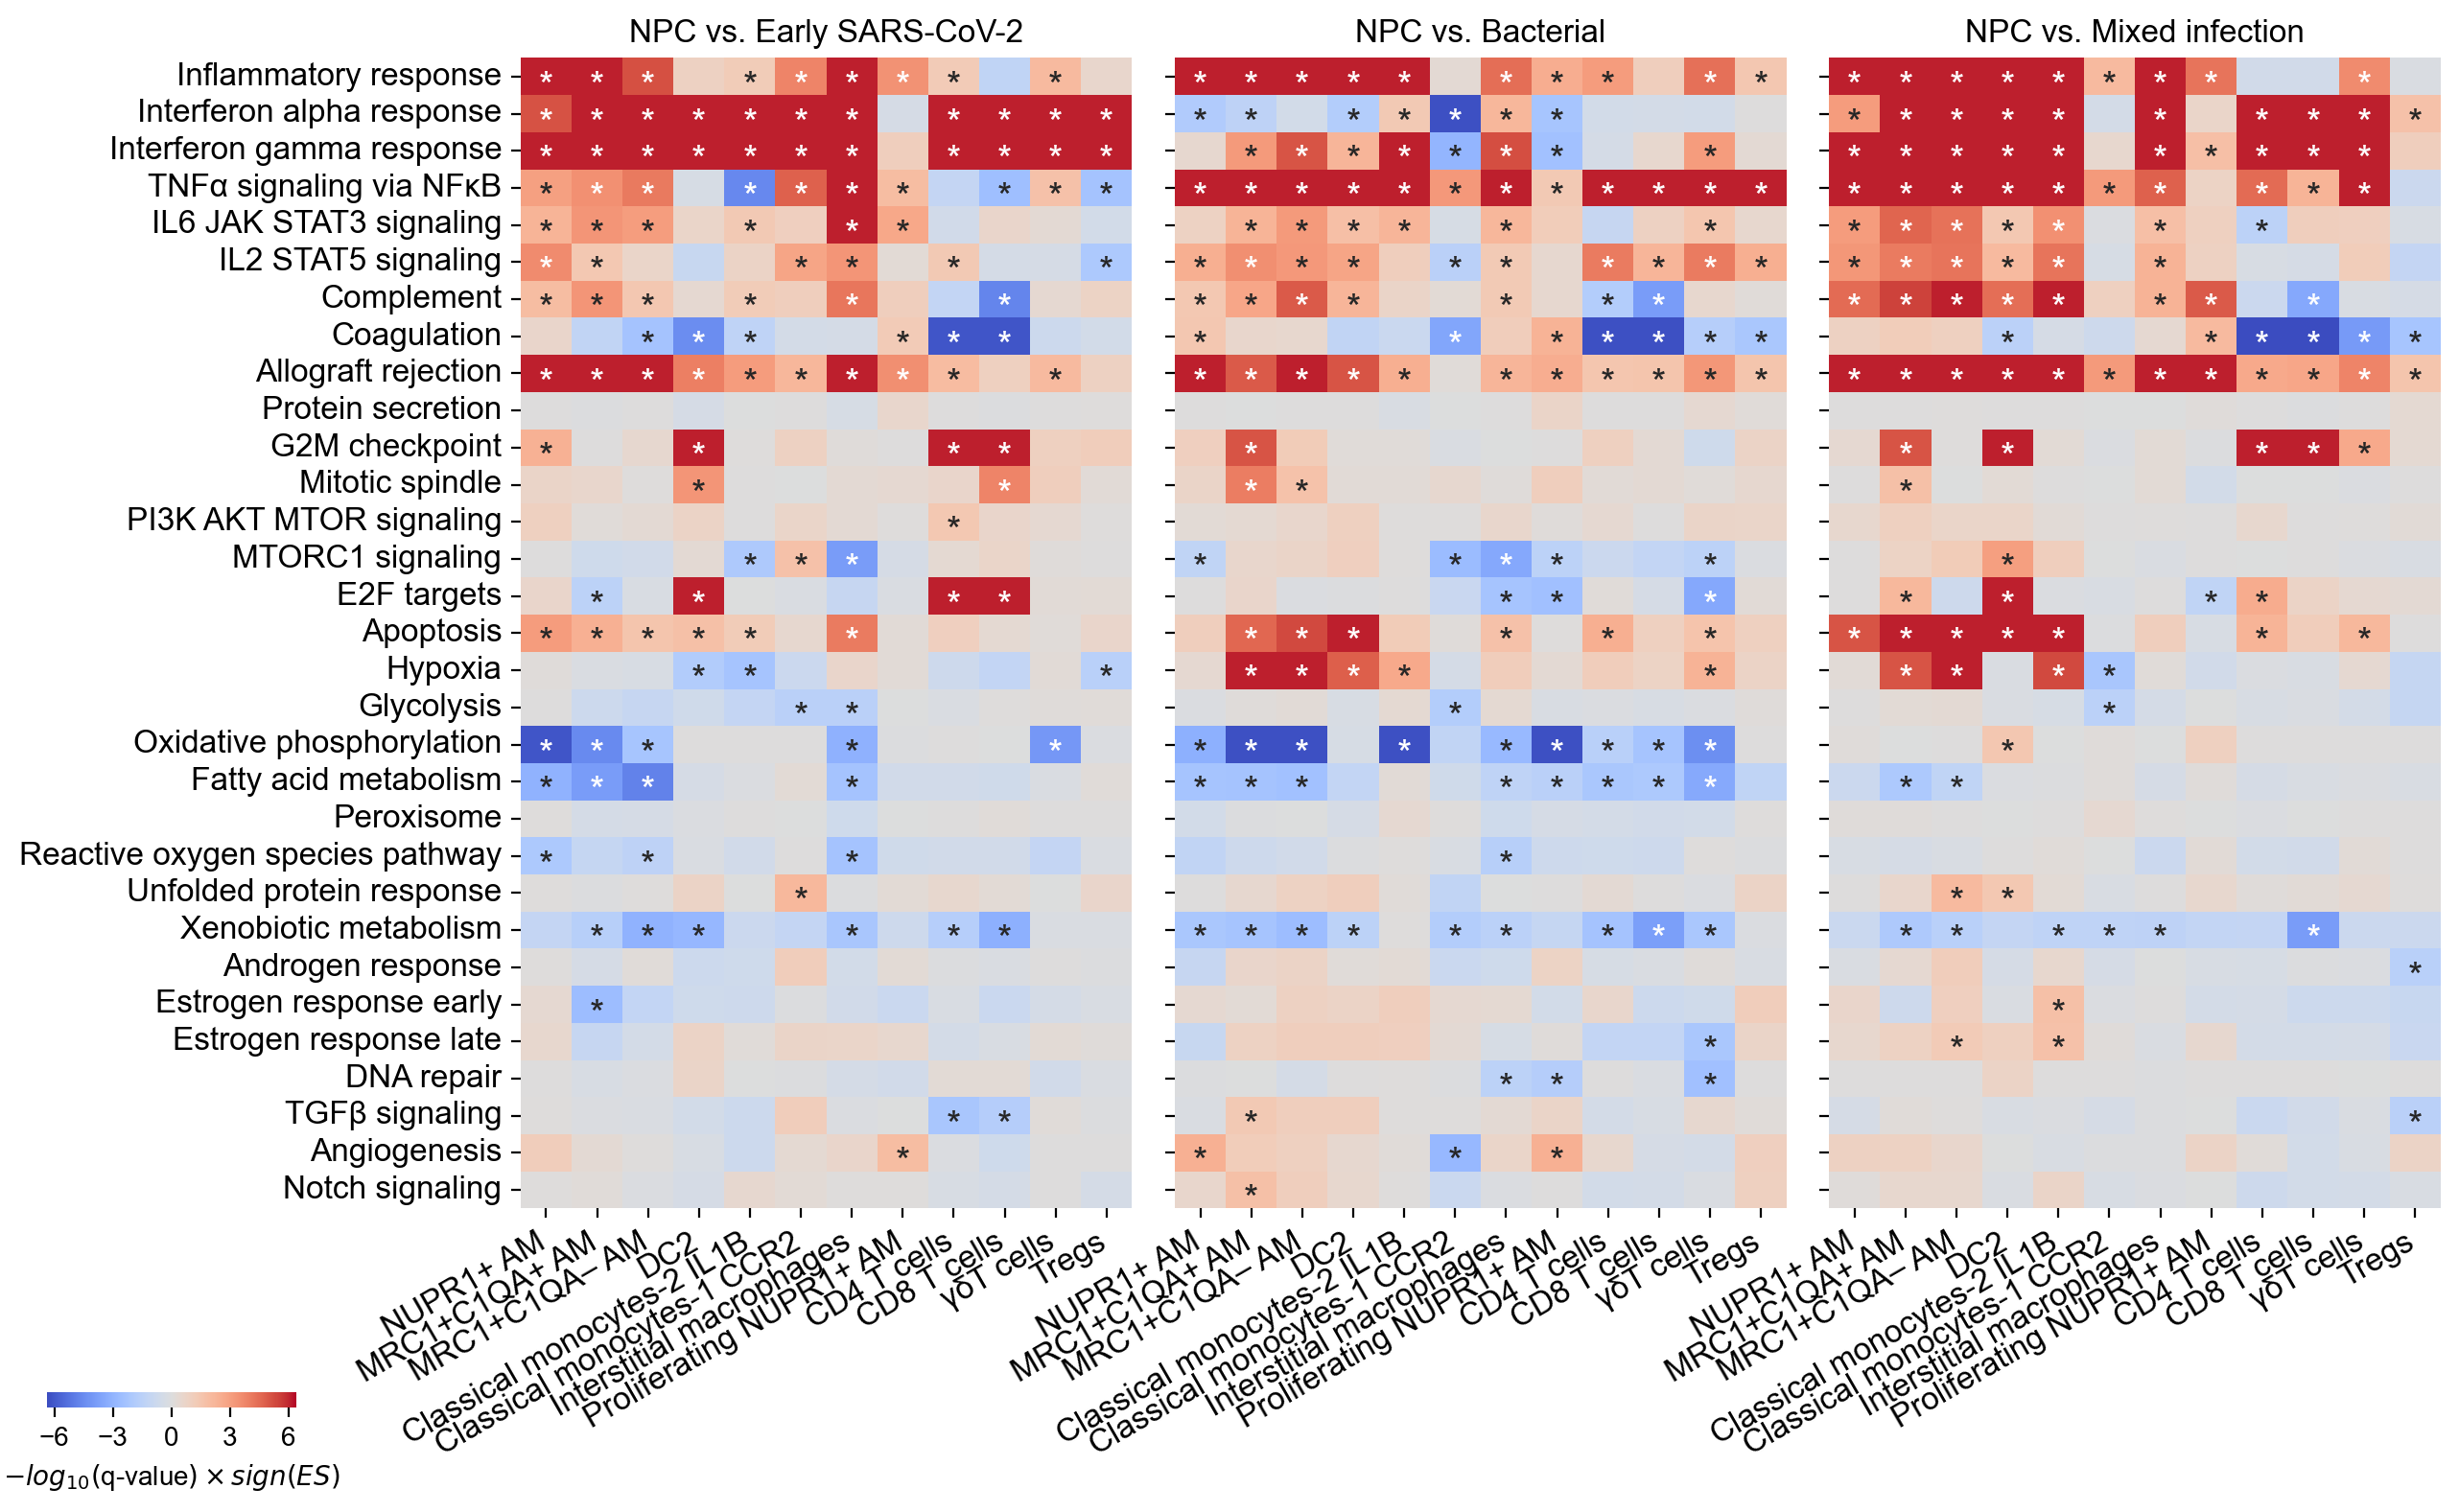

In [ ]:
fig, axes = plt.subplots(
    1, len(GSEAS_TO_PLOT), constrained_layout=False,
    figsize=(13, 8), sharey=True, gridspec_kw=dict(wspace=0.07)
)
for i, gsea_df_plot in enumerate(to_plot):
    ax = axes[i]

    present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
    present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
    gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]
    gsea_df_plot.columns = pd.Series(gsea_df_plot.columns).replace(CELL_TYPES_DISPLAY)

    rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

    stars = np.empty_like(gsea_df_plot, dtype=str)
    stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

    cg = sns.heatmap(
        gsea_df_plot,
        cbar=False,
        xticklabels=gsea_df_plot.columns,
        yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
        cmap='coolwarm',
        annot=stars,
        fmt='',
        annot_kws=dict(
            va='center_baseline',
            fontsize=14
        ),
        ax=ax,
        vmin=plot_min,
        vmax=plot_max,
        center=0
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(
        ax.get_xticklabels(),
        fontsize=12,
        rotation=30,
        ha='right'
    )
    ax.set_title(TITLES[GSEAS_TO_PLOT[i]], fontsize=12)
    trans = mpl.transforms.Affine2D().translate(5, 0)
    for t in ax.get_xticklabels():
        t.set_transform(t.get_transform() + trans)
    for t in ax.texts:
        if t.get_text() == '*':
            p = t.get_position()
            t.set_position((p[0], p[1] + 0.2))
    if i == 0:
        ax.tick_params(axis='y', labelsize=12)

norm = mpl.colors.CenteredNorm(vcenter=0)
norm.vmin = plot_min
norm.vmax = plot_max
cax = fig.add_axes((0.03, 0.07, 0.1, 0.01))
mappable = mpl.cm.ScalarMappable(norm, cmap='coolwarm')
cbar = plt.colorbar(mappable, cax=cax, orientation='horizontal')
for spine in cax.spines:
    cax.spines[spine].set_visible(False)
cax.set_xlabel('$-log_{10}($q-value$) \\times sign(ES)$')
cax.set_xticks([-6, -3, 0, 3, 6])
fig.subplots_adjust(left=0.22, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70a_gsea_pathogens_npc.pdf')

# 4. GSEA Viral vs Bacterial

In [48]:
gsea = result['eCOVID_vs_Bac']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.1

print(f'P-values exactly 0: {idx.sum()} in eCOVID_vs_Bac')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 73 in eCOVID_vs_Bac


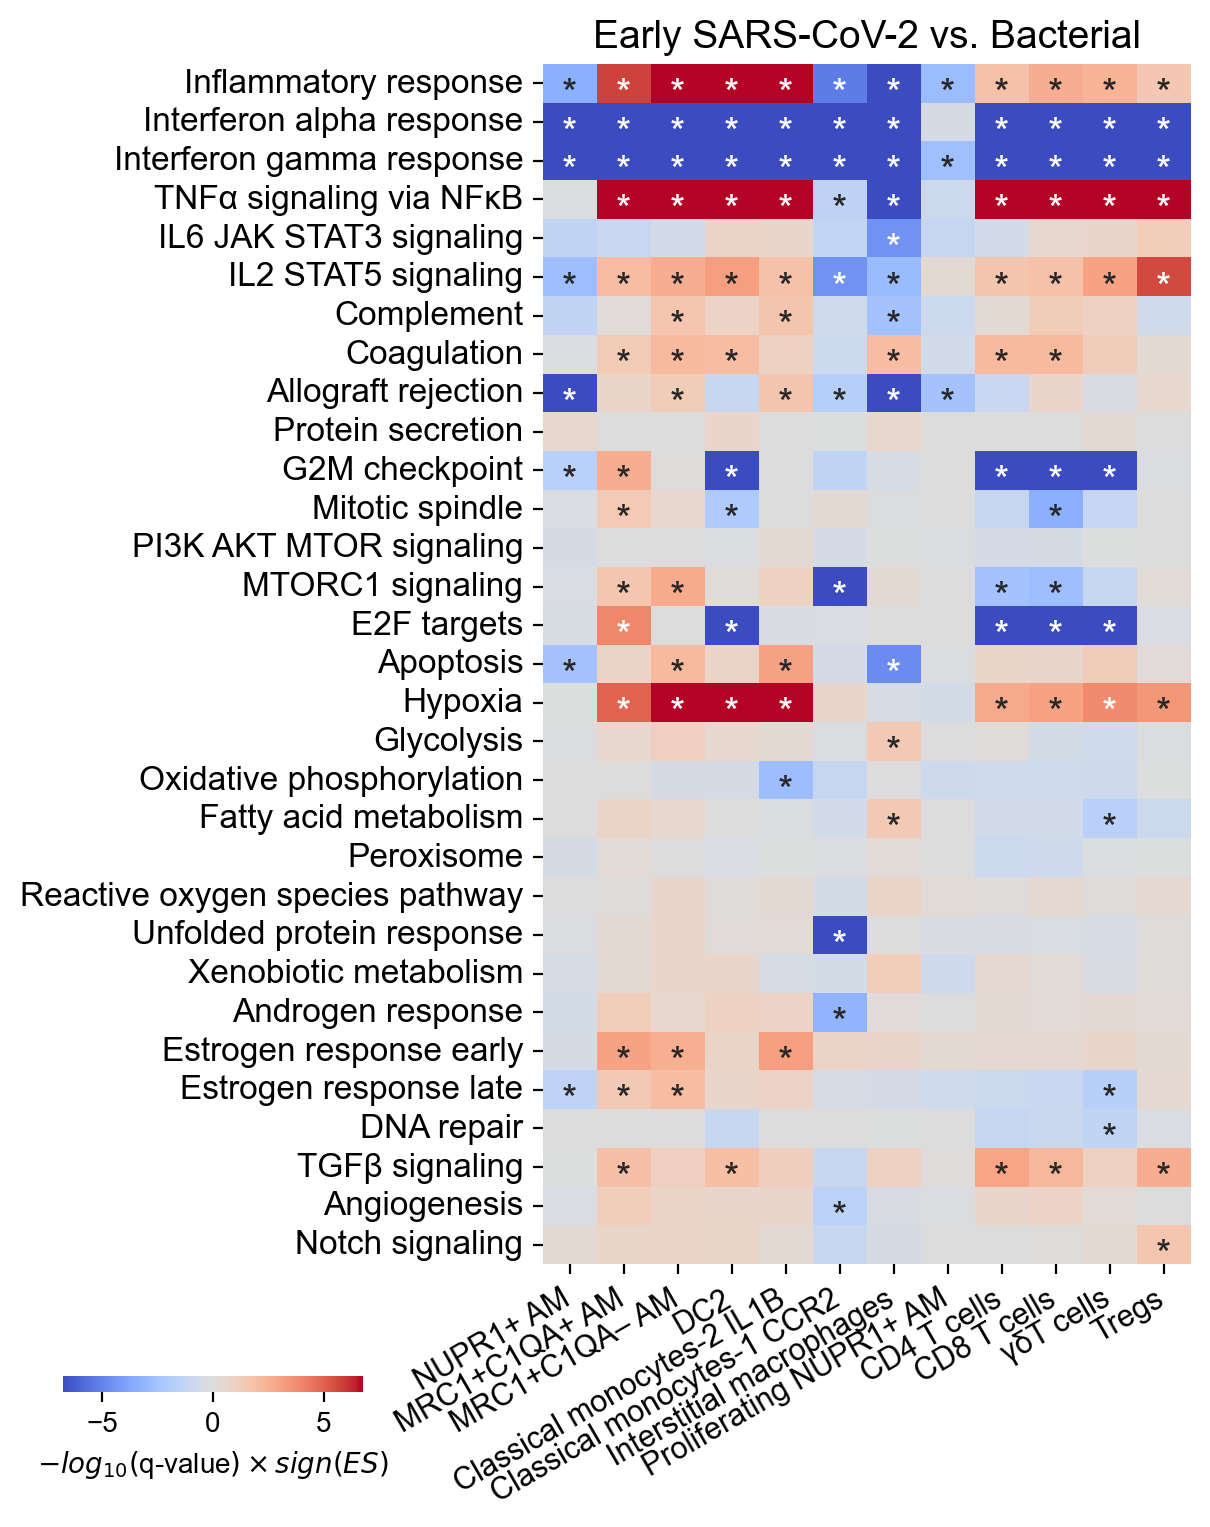

In [ ]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(6, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]
gsea_df_plot.columns = pd.Series(gsea_df_plot.columns).replace(CELL_TYPES_DISPLAY)

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12)
ax.set_title('Early SARS-CoV-2 vs. Bacterial', fontsize=14)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/70a_gsea_viral_vs_bac.pdf')

# 5. Viral vs Bacterial MA plots

To visualize genes in MA, we will only highlight secretome, accessible from https://www.proteinatlas.org/humanproteome/subcellular/secreted+proteins
and downloadable from https://www.proteinatlas.org/search/protein_class%3APredicted+secreted+proteins

In [50]:
CELL_TYPES_TO_PLOT_MA = [
    'Classical_monocytes-2_IL1B', 'MRC1+C1QA+', 'CD8_T_cells', 'CD4_T_cells'
]

In [51]:
GENES_TO_HIGHLIGHT = {
    'MRC1+C1QA+': [
        'CXCL11', 'CXCL10', 'CCL8', 'CCL7', 'TNFSF10',
        'TNF', 'IL1B', 'CXCL8', 'CXCL2', 'CXCL3', 'SPINK1', 'C15orf48',
    ],
    'Classical_monocytes-2_IL1B': [
        'IL6', 'IL1B', 'CXCL2', 'CXCL8', 'CXCL1', 'SPINK1', 'CCL4', 'CCL20',
        'CXCL10', 'CXCL11', 'ISG15', 'CCL8', 'DEFB1', 'TNFSF10', 'HAPLN3', 'TIMP4', 'IFI27',
    ],
    'CD8_T_cells': [
        'CCL20', 'IL1B', 'CXCL3', 'CXCL8', 'NR4A2', 'IL26', 'FOSB', 'AREG', 'CCL18', 'VEGFA',
        'IFI27', 'IFIT1', 'CXCL10', 'IFI44L', 'IFIT3', 'ISG15', 'UHRF1', 'IFI44', 'AURKA',
    ],
    'CD4_T_cells': [
        'IL1B', 'IL2', 'CSF2', 'BATF3', 'FOSB', 'NR4A2', 'CCL20', 'AREG', 'IL1R1', 'IKZF2',
        'IFI27', 'CXCL10', 'IFI44L', 'IFIT1', 'CXCL13', 'UHRF1', 'LAG3', 'MKI67', 'CCL2', 'CCL5',
    ]
}

In [52]:
secretome = pd.read_table('protein_class_Predicted.tsv')

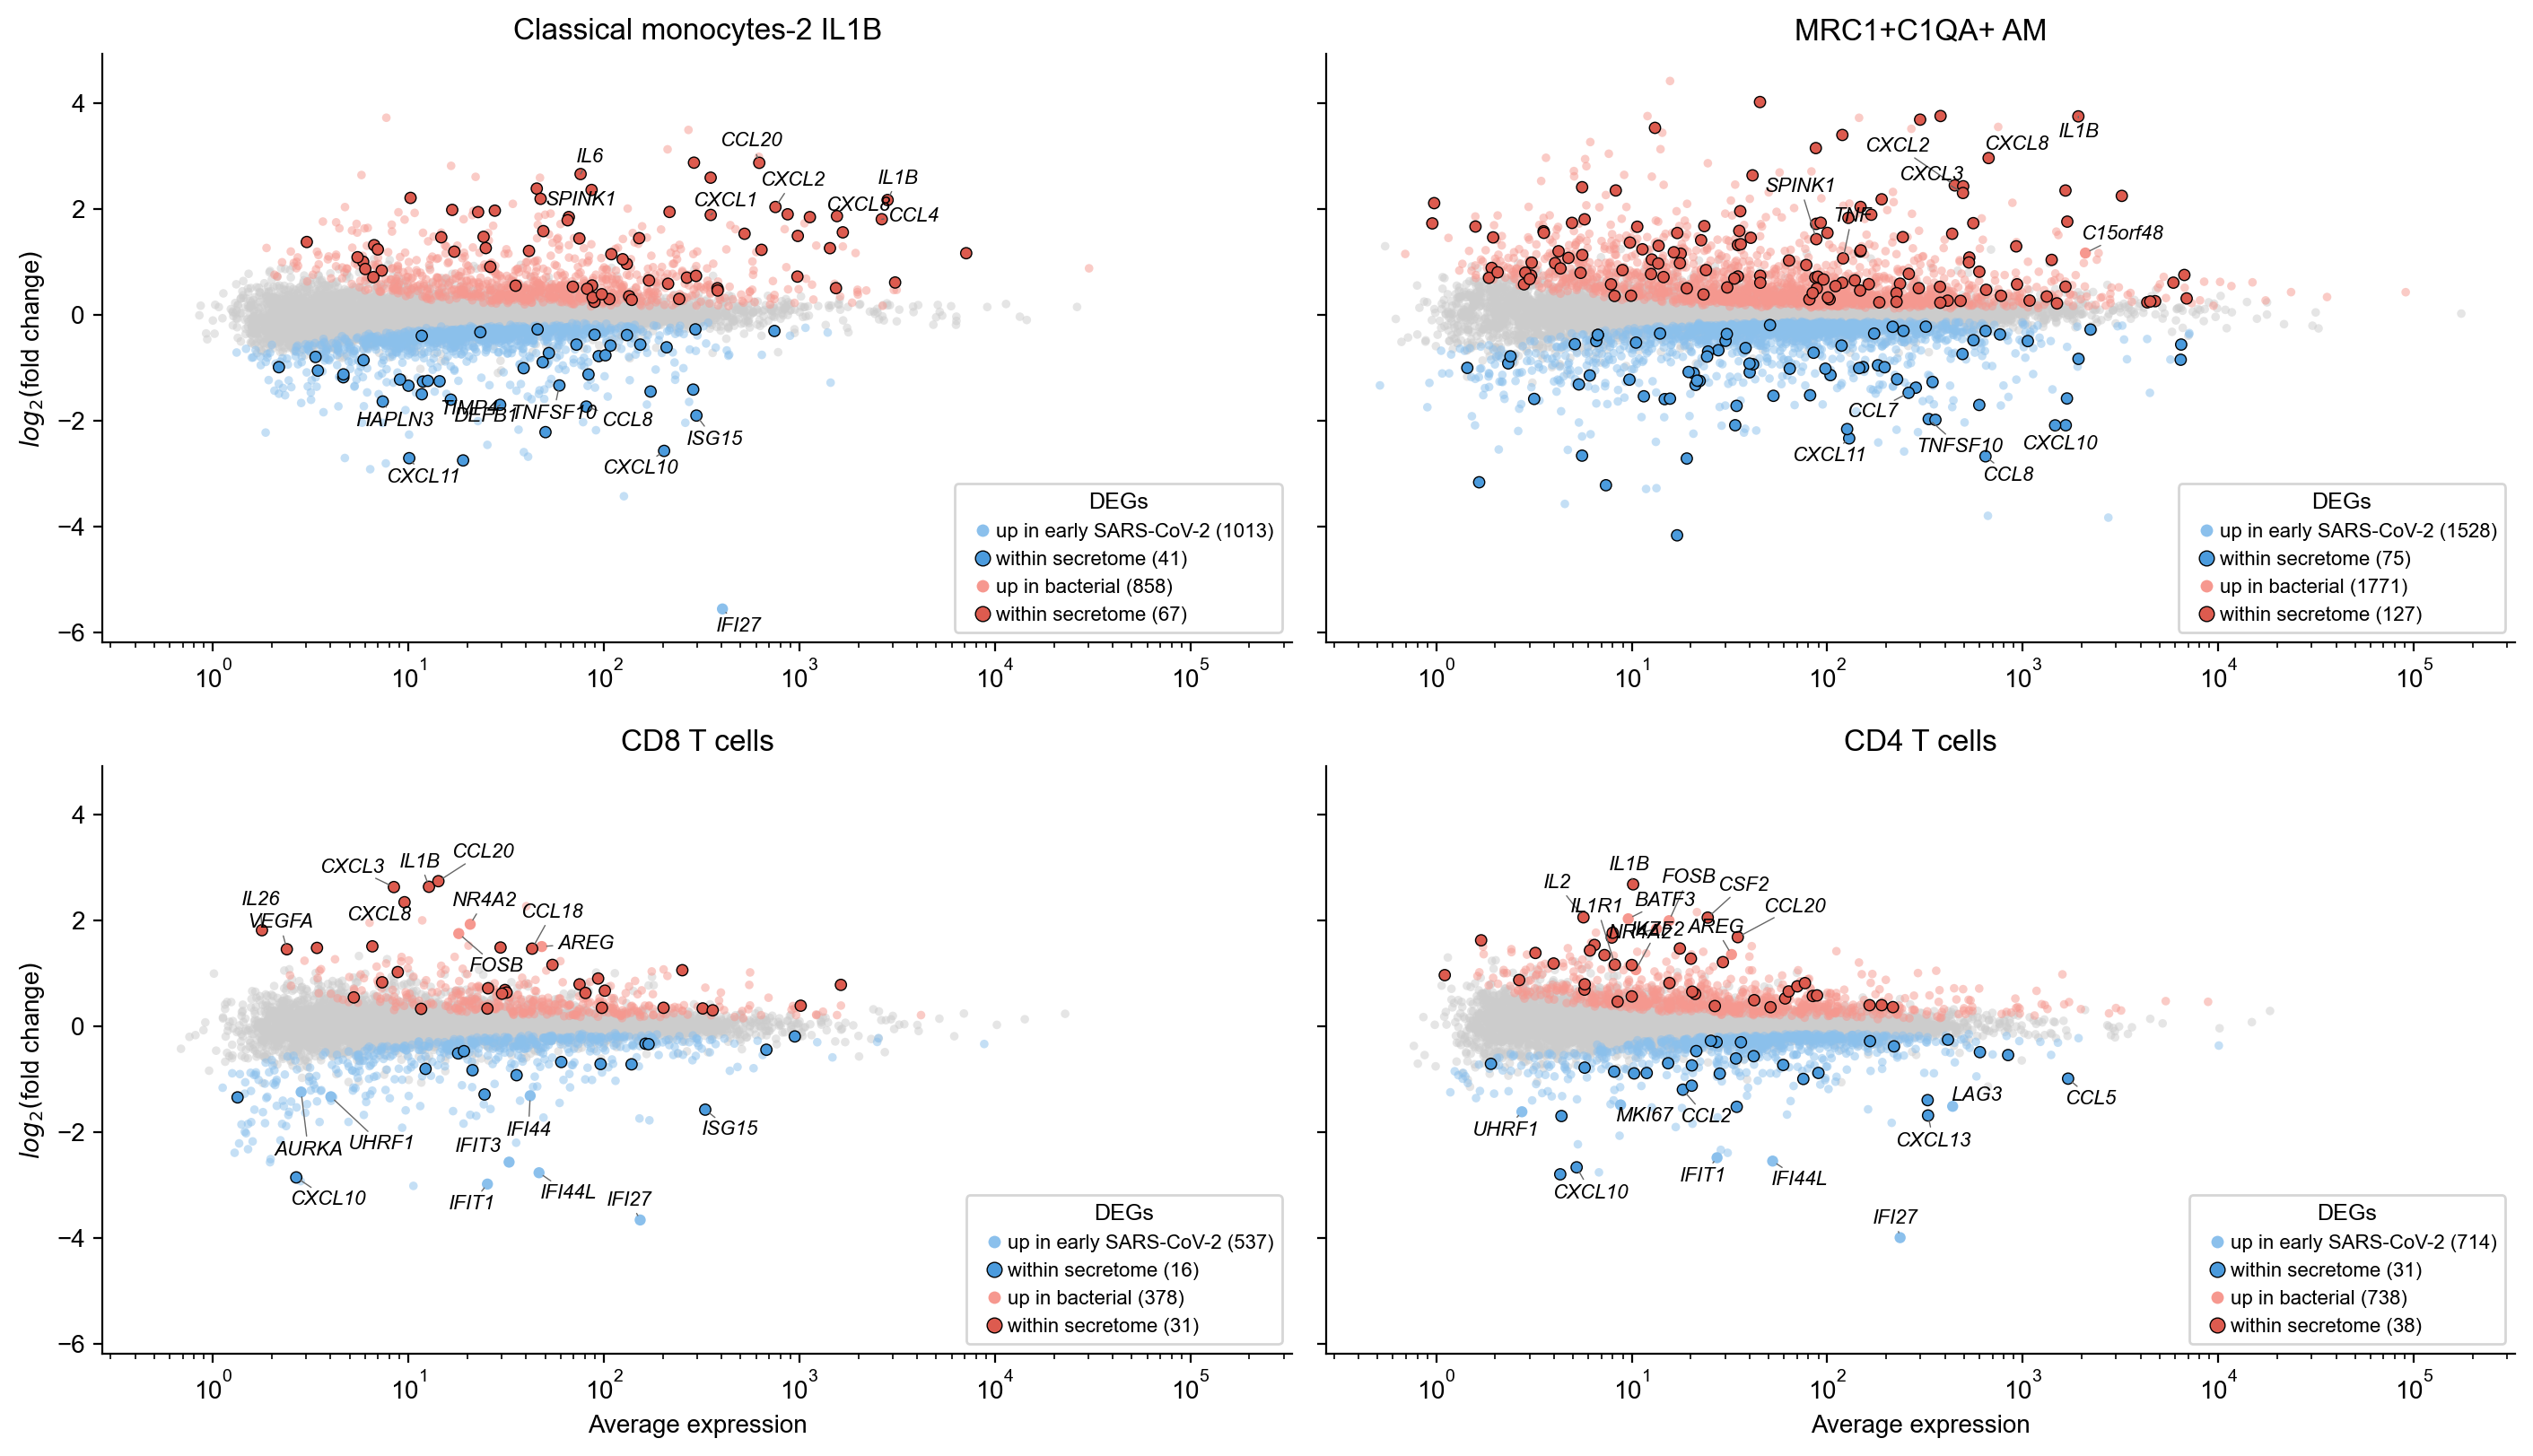

In [ ]:
fig, axes = plt.subplots(2, 2, constrained_layout=True, figsize=(14, 8), sharey=True, sharex=True, gridspec_kw=dict(hspace=0.05))
all_texts = []
ma_degs = {}
for i, cell_type in enumerate(CELL_TYPES_TO_PLOT_MA):
    ax = axes[i // 2, i % 2]

    degs = data['Early SARS-CoV-2_vs_Bacteria'].info[cell_type].comparisons[0].genes.copy()
    degs = degs.sort_values('log2FoldChange')
    control_idx = degs.padj.lt(0.05) & degs.log2FoldChange.lt(0)
    condition_idx = degs.padj.lt(0.05) & degs.log2FoldChange.gt(0)
    secretome_idx = degs.index.isin(secretome.Gene)
    ma_degs[cell_type] = degs.copy()
    ma_degs[cell_type]['secretome'] = secretome_idx
    # degs = degs.loc[degs.index.isin(secretome.Gene)]
    highlight = GENES_TO_HIGHLIGHT.get(cell_type)
    if highlight is None:
        highlight = (
            list(degs.loc[control_idx].head(10).index)
            + list(degs.loc[condition_idx].tail(10).index)
        )
    highlight_idx = degs.index.isin(highlight)

    degs['color'] = '#cccccc'
    degs['order'] = 0
    degs['alpha'] = 0.5
    degs['edgewidths'] = 0
    degs['size'] = 12

    degs.loc[control_idx & ~secretome_idx, 'color'] = "#8bc0ec"
    degs.loc[control_idx & ~secretome_idx, 'order'] = 3
    degs.loc[condition_idx & ~secretome_idx, 'color'] = "#f6988f"
    degs.loc[condition_idx & ~secretome_idx, 'order'] = 3
    degs.loc[control_idx & ~secretome_idx & highlight_idx, 'size'] = 20
    degs.loc[control_idx & ~secretome_idx & highlight_idx, 'order'] = 4
    degs.loc[control_idx & ~secretome_idx & highlight_idx, 'alpha'] = 1
    degs.loc[condition_idx & ~secretome_idx & highlight_idx, 'size'] = 20
    degs.loc[condition_idx & ~secretome_idx & highlight_idx, 'order'] = 4
    degs.loc[condition_idx & ~secretome_idx & highlight_idx, 'alpha'] = 1
    degs.loc[control_idx & secretome_idx, 'color'] = '#4b9bdd'
    degs.loc[control_idx & secretome_idx, 'order'] = 5
    degs.loc[control_idx & secretome_idx, 'alpha'] = 1
    degs.loc[control_idx & secretome_idx, 'size'] = 20
    degs.loc[control_idx & secretome_idx, 'edgewidths'] = 0.5
    degs.loc[condition_idx & secretome_idx, 'color'] = '#dd5b4f'
    degs.loc[condition_idx & secretome_idx, 'order'] = 5
    degs.loc[condition_idx & secretome_idx, 'alpha'] = 1
    degs.loc[condition_idx & secretome_idx, 'size'] = 20
    degs.loc[condition_idx & secretome_idx, 'edgewidths'] = 0.5

    degs = degs.sort_values('order')
    ax.scatter(
        degs.baseMean,
        degs.log2FoldChange,
        c=degs.color,
        s=degs['size'],
        alpha=degs.alpha,
        edgecolors='k',
        linewidths=degs.edgewidths
    )

    ax.set_xscale('log')
    ax.set_title(cell_type.replace('_', ' ').replace('MRC1+C1QA+', 'MRC1+C1QA+ AM'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelbottom=True)
    if i % 2 == 0:
        ax.set_ylabel('$log_2($fold change$)$')
    if i // 2 == 1:
        ax.set_xlabel('Average expression')
    legend = []
    legend.append(mpl.lines.Line2D(
        [0], [0],
        label=f'up in early SARS-CoV-2 ({control_idx.sum()})',
        color='#ffffffff',
        markerfacecolor='#8bc0ec',
        marker='o',
        markersize=6
    ))
    legend.append(mpl.lines.Line2D(
        [0], [0],
        label=f'within secretome ({(control_idx & secretome_idx).sum()})',
        color='#ffffffff',
        markerfacecolor='#4b9bdd',
        marker='o',
        markeredgecolor='black',
        markeredgewidth=0.5,
        markersize=6
    ))
    legend.append(mpl.lines.Line2D(
        [0], [0],
        label=f'up in bacterial ({condition_idx.sum()})',
        color='#ffffffff',
        markerfacecolor='#f6988f',
        marker='o',
        markersize=6
    ))
    legend.append(mpl.lines.Line2D(
        [0], [0],
        label=f'within secretome ({(condition_idx & secretome_idx).sum()})',
        color='#ffffffff',
        markerfacecolor='#dd5b4f',
        marker='o',
        markeredgecolor='black',
        markeredgewidth=0.5,
        markersize=6
    ))
    ax.legend(
        handles=legend,
        fontsize=8,
        frameon=True,
        handletextpad=-0.3,
        loc='lower right',
        bbox_to_anchor=(1.0, 0.0),
        title='DEGs',
        title_fontsize=9
    )
    texts = []
    for gene, r in degs.loc[highlight].iterrows():
        texts.append(
            ax.text(r.baseMean, r.log2FoldChange, gene, ha='center', va='center', fontstyle='italic', fontsize=8)
        )
    adjustText.adjust_text(
        texts,
        objects=ax.collections[0],
        arrowprops=dict(arrowstyle="-", color='#666666', lw=0.5),
        force_static=(0.1, 0.4),
        expand=(1.1, 1.4),
        iter_lim=10,
        ax=ax
    )
    ax.collections[0].set_rasterized(True)

fig.savefig('00_plots/70a_ma_viral_vs_bac.pdf', dpi=300)

## 5.2 MRC1+C1QA+ for serial baseline comparison

With all IFNg response genes highlighted

In [ ]:
data = joblib.load('40c_deg_data.joblib')

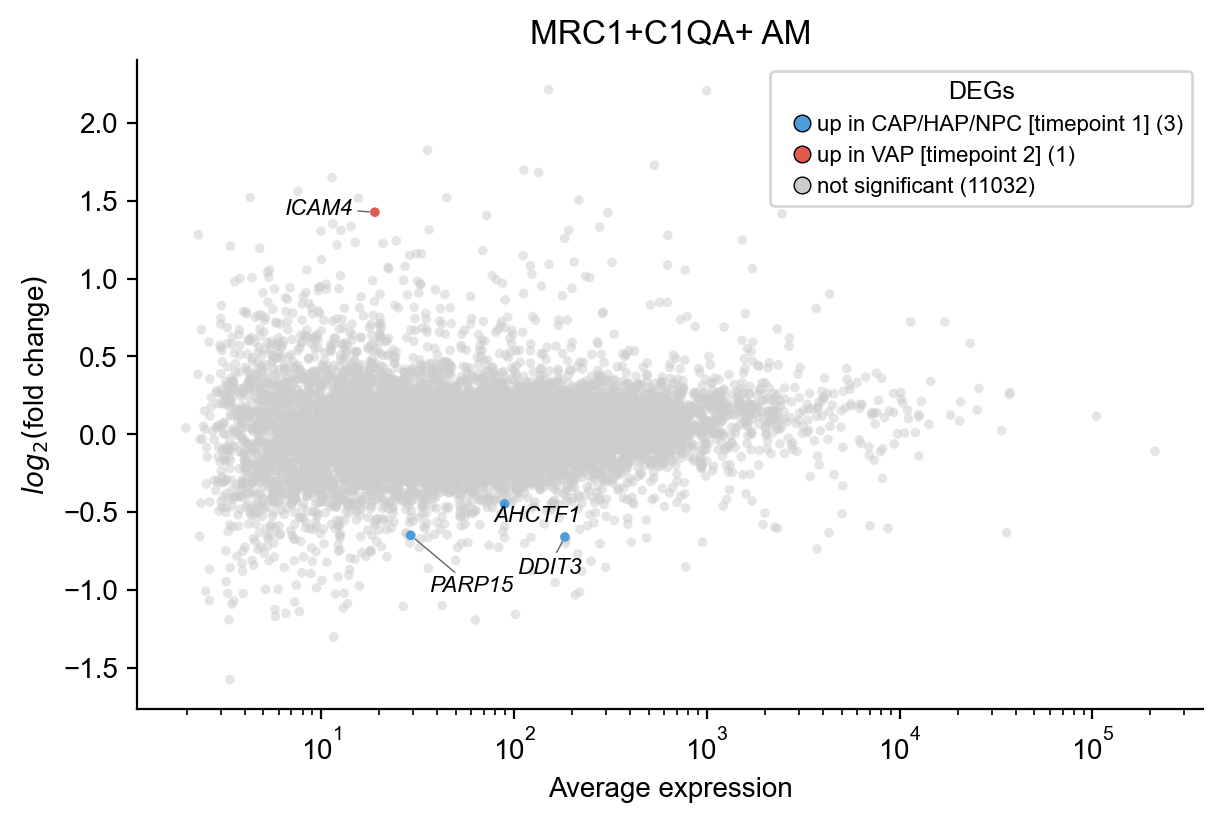

In [ ]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 4))

degs = data['vap'].info['MRC1+C1QA+'].comparisons[0].genes.copy()
# degs = degs.loc[degs.index.isin(secretome.Gene)]

degs['color'] = '#cccccc'
degs['order'] = 0
degs['alpha'] = 0.5
degs['edgewidths'] = 0
degs['size'] = 12
control_idx = degs.padj.lt(0.05) & degs.log2FoldChange.lt(0)
condition_idx = degs.padj.lt(0.05) & degs.log2FoldChange.gt(0)
degs.loc[control_idx, 'color'] = '#4b9bdd'
degs.loc[control_idx, 'order'] = 1
degs.loc[condition_idx, 'color'] = '#dd5b4f'
degs.loc[condition_idx, 'order'] = 2
degs.loc[control_idx | condition_idx, 'alpha'] = 1
degs = degs.sort_values('order')
ax.scatter(degs.baseMean, degs.log2FoldChange, c=degs.color, s=degs['size'], alpha=degs.alpha, edgecolors='k', linewidths=degs.edgewidths)

ax.set_xscale('log')
ax.set_title('MRC1+C1QA+ AM')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelbottom=True)
ax.set_ylabel('$log_2($fold change$)$')
ax.set_xlabel('Average expression')
legend = []
legend.append(mpl.lines.Line2D(
    [0], [0],
    label=f'up in CAP/HAP/NPC [timepoint 1] ({control_idx.sum()})',
    color='#ffffffff',
    markerfacecolor='#4b9bdd',
    marker='o',
    markeredgecolor='k',
    markeredgewidth=0.5,
    markersize=6
))
legend.append(mpl.lines.Line2D(
    [0], [0],
    label=f'up in VAP [timepoint 2] ({condition_idx.sum()})',
    color='#ffffffff',
    markerfacecolor='#dd5b4f',
    marker='o',
    markeredgecolor='k',
    markeredgewidth=0.5,
    markersize=6
))
legend.append(mpl.lines.Line2D(
    [0], [0],
    label=f'not significant ({(degs.shape[0] - condition_idx.sum() - control_idx.sum())})',
    color='#ffffffff',
    markerfacecolor='#cccccc',
    marker='o',
    markeredgecolor='k',
    markeredgewidth=0.5,
    markersize=6
))
ax.legend(
    handles=legend,
    fontsize=8,
    frameon=True,
    handletextpad=-0.3,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.0),
    title='DEGs',
    title_fontsize=9
)
texts = []
for gene, r in degs.loc[control_idx].sort_values('log2FoldChange').head(10).iterrows():
    if r.log2FoldChange > 0:
        break
    texts.append(
        ax.text(r.baseMean, r.log2FoldChange, gene, ha='center', va='center', fontstyle='italic', fontsize=8)
    )
for gene, r in degs.loc[condition_idx].sort_values('log2FoldChange').tail(10).iterrows():
    if r.log2FoldChange < 0:
        continue
    texts.append(
        ax.text(r.baseMean, r.log2FoldChange, gene, ha='center', va='center', fontstyle='italic', fontsize=8)
    )
adjustText.adjust_text(
    texts,
    objects=ax.collections[0],
    arrowprops=dict(arrowstyle="-", color='#666666', lw=0.5),
    force_static=(0.1, 0.4),
    expand=(1.1, 1.4),
    iter_lim=10,
    ax=ax
)
ax.collections[0].set_rasterized(True)
fig.savefig('00_plots/70a_ma_serial_vap.pdf', dpi=300)

# 6. Alive vs Dead GSEA

In [ ]:
data = joblib.load('20c_deg_data.joblib')

In [ ]:
A_VS_D_BASE = pathlib.Path('../data/05_pseudobulk/20c_degs')

In [59]:
result = {}
for _, task in data.items():
    gseas = []
    for k, ct_info in task.info.items():
        comp = ct_info.comparisons[0]
        gsea_path = A_VS_D_BASE / task.task_info.pathname / k / 'gsea.csv'
        if not gsea_path.exists():
            print(f'No GSEA for {k} in {task.task_info.pathname}')
            continue
        gsea = pd.read_csv(gsea_path, index_col=0)
        gsea['cell_type'] = k
        if k == 'Perivascular_macrophages':
            gsea['cell_type'] = 'Interstitial_macrophages'
        gseas.append(gsea)
    result[task.task_info.pathname] = pd.concat(gseas)

In [60]:
gsea = result['alive_vs_dead']
gsea['p-value'] = gsea['NOM p-value'].copy()
idx = gsea['p-value'].eq(0)
min_p_val = gsea['p-value'][~idx].min()
gsea.loc[idx, 'p-value'] = min_p_val * 0.1

print(f'P-values exactly 0: {idx.sum()} in alive_vs_dead')

gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
gsea['-log10(padj)'] = -np.log10(gsea.padj)
gsea['-log10(padj)'] *= np.sign(gsea.NES)
gsea_df = gsea.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
)
gsea_df = gsea_df.loc[:, GSEA_LIST]
gsea_df.index = gsea_df.index.str.replace('_', ' ')

gsea_df_plot = gsea_df.fillna(0).T

P-values exactly 0: 49 in alive_vs_dead


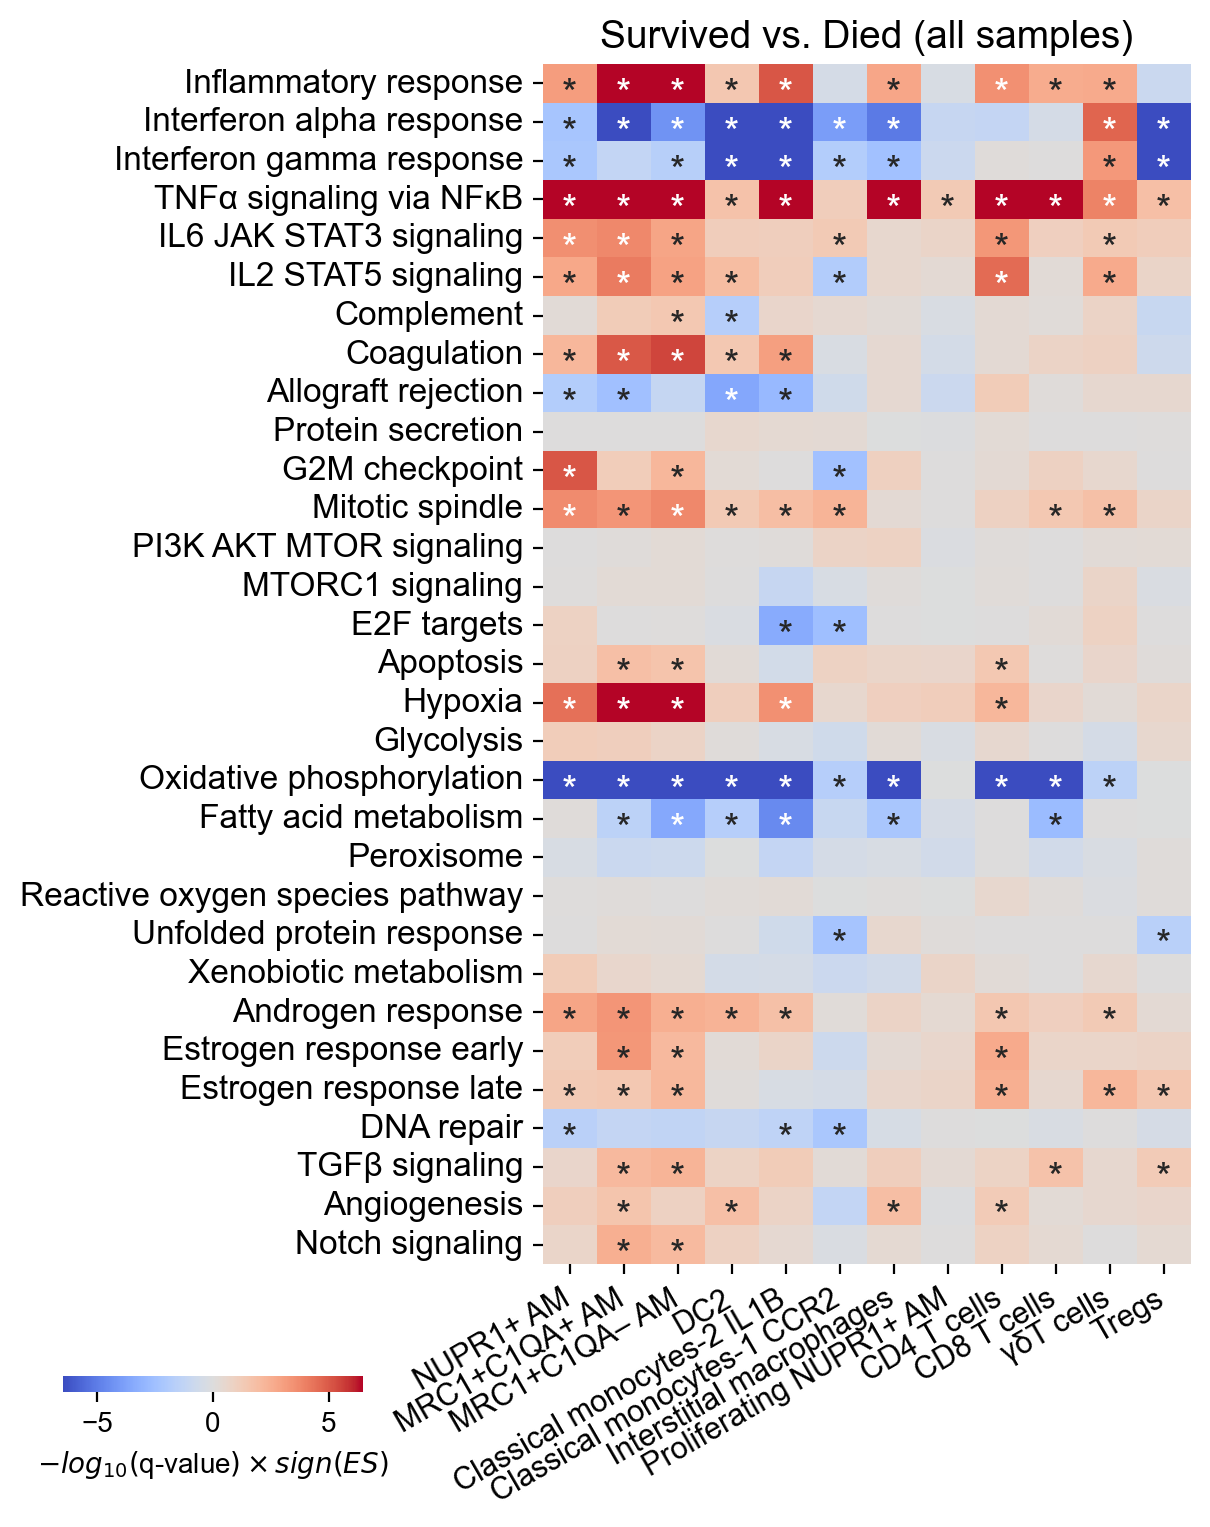

In [61]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(6, 8))

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

present_cell_types = pd.Series(MAIN_CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]
gsea_df_plot.columns = pd.Series(gsea_df_plot.columns).replace(CELL_TYPES_DISPLAY)

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cax = fig.add_axes((0.05, 0.12, 0.25, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cax,
    xticklabels=gsea_df_plot.columns,
    yticklabels=[pb_utils.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    cbar_kws=dict(
        label='$-log_{10}($q-value$) \\times sign(ES)$',
        orientation='horizontal'
    ),
    ax=ax,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=11,
    rotation=30,
    ha='right'
)
# ax.set_title(ORDER[1 + i], fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

ax.tick_params(axis='y', labelsize=12, left=True)
ax.tick_params(axis='x', bottom=True)
ax.set_title('Survived vs. Died (all samples)', fontsize=14)

fig.subplots_adjust(left=0.45, bottom=0.2, top=0.95, right=0.99)
fig.savefig('00_plots/77a_gsea_alive_vs_dead.pdf')